In [1]:
import os
import gc
import time
import gseapy as gp

from pathlib import Path
from collections import Counter
from functools import reduce

import numpy as np
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests

import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
from matplotlib_venn import venn2, venn3
from matplotlib.lines import Line2D
import matplotlib as mpl

from upsetplot import from_contents, generate_counts, UpSet, plot, from_indicators
from pycirclize import Circos

import seaborn as sns

import anndata as ad
import scanpy as sc

%matplotlib inline

In [2]:
## FDR Calculation Function ##

def fdr_per_celltype(dge_df):
    """Add FDR-adjusted p-values and significance per cell type."""
    dge_df['p.adjusted'] = None
    dge_df['significant_fdr'] = False
    
    for celltype, group in dge_df.groupby('assay'):
        rejected, pvals_corrected, _, _ = multipletests(group['p.value'], method='fdr_bh')
        dge_df.loc[group.index, 'p.adjusted'] = pvals_corrected
        dge_df.loc[group.index, 'significant_fdr'] = rejected
    
    return dge_df

In [3]:
# ## Import AnnData Object ##

# adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_annotated_w_celltypist_scanvi.h5ad')

# ## Toss Stressed Glia & Doublets ##

# adata = adata[~(adata.obs['subclass_annotations'] == 'Stressed Glia') & ~adata.obs['pred_dbl']].copy()
# gc.collect()

# # Create Pseudobulk Col ##

# adata.obs['Donor_Sample'] = adata.obs['Donor'].astype('str') + '_' + adata.obs['Sample Name'].astype('str')

In [4]:
# ## Known Genes In Deleted Regions ##

# # https://bioinfo.uth.edu/SZGR/display/showGeneset #

# CLASSIC_22q11 = ['TBX1', "COMT", "DGCR8", "TANGO2"]

# ALL_22q11 = ["DERL3", "LRP5L", "SGSM1", "C22orf15", "LOC284890", "C22orf36", "PIWIL3", "GSTT2B",
#                     "DDTL", "SMARCB1", "VPREB3", "SERPIND1", "MAPK1", "HIRA", "ZNF74", "CLTCL1",
#                     "VPREB1", "GSTT2", "MMP11", "ZNF70", "CRYBB1", "CRKL", "BCR", "ADRBK2",
#                     "MN1", "CHEK2", "APOL2", "C22orf28", "LOC652968", "FBXO7", "PVALB", "PPARA",
#                     "TPST2", "PES1", "SEZ6L", "PITPNB", "TFIP11", "C22orf31", "ASPHD2", "KREMEN1",
#                     "ZNRF3", "ASCC2", "HSCB", "CCDC117", "RHBDD3", "C22orf24", "TIMP3", "TBC1D10A",
#                     "XBP1", "EWSR1", "LIF", "LIMK2", "DRG1", "NEFH", "NF2", "OSM",
#                     "RFPL1", "SMTN", "TCN2", "NIPSNAP1", "THOC5", "MTMR3", "GAL3ST1", "SFI1",
#                     "SF3A1", "RASL10A", "GAS2L1", "MORC2", "SEC14L2", "PATZ1", "PISD", "OSBP2",
#                     "RNF185", "PIK3IP1", "EMID1", "SELM", "HORMAD2", "DUSP18", "CABP7", "RNF215",
#                     "SEC14L3", "SEC14L4", "SLC35E4", "LOC550631", "SLC5A4", "C22orf30", "DGCR5",
#                     "DGCR6L", "SUSD2", "SCZD4", "BID", "IL17RA", "BCL2L13", "TUBA8", "GAB4",
#                     "CCT8L2", "XKR3", "TRMT2A", "RTDR1", "CECR2", "YPEL1", "LOC51233", "MED15",
#                     "UPB1", "CECR1", "DGCR8", "GNB1L", "EIF4ENIF1", "SLC2A11", "THAP7", "OR11H1",
#                     "C22orf13", "SLC25A18", "MYO18B", "CRYBB2", "CRYBB3", "CRYBA4", "PLA2G3",
#                     "APOL4", "ACO2", "ARVCF", "GSC2", "PI4KA", "SEPT5", "PRODH", "RANBP1",
#                     "SLC7A4", "SLC25A1", "TBX1", "CLDN5", "UBE2L3", "UFD1L", "CDC45L", "SNAP29",
#                     "DGCR2", "TXNRD2", "USP18", "HIC2", "TSSK2", "SDF2L1", "PPIL2", "ZDHHC8",
#                     "PEX26", "MICAL3", "MRPL40", "RTN4R", "C22orf29", "KLHL22", "SCARF2",
#                     "C22orf25", "AIFM3", "CCDC116", "FLJ42953", "LOC440792", "COMT", "GP1BB",
#                     "DGCR6", "LZTR1", "DGCR14", "GNAZ", "TOP3B", "RAB36", "PPM1F", "PRAME",
#                     "DKFZP434P211", "LOC96610", "ZNF280A", "ZNF280B", "ADORA2A", "DDT",
#                     "GGT1", "GSTT1", "IGLL1", "MIF", "SNRPD3", "SPECC1L", "CABIN1"]

# CLASSIC_3q29 = ['DLG1', "PAK2", "TFRC", "C3orf34"]
# BORDERLINE_3q29 = ['HES1', "CLDN1", "OPA1"]
# ALL_3q29 = adata.var_names[adata.var_names.isin(CLASSIC_3q29 + BORDERLINE_3q29)].tolist()

# CLASSIC_15q13 = ['HERC2', 'CHRFAM7A', 'CHP', 'FMN1']
# BORDERLINE_15q13 = ['SCG5', 'SLC12A6', 'GREM1', 'MAP1A']
# ALL_15q13 = adata.var_names[adata.var_names.isin(CLASSIC_15q13 + BORDERLINE_15q13)].tolist()

In [5]:
## Read in DEG Lists ##

CSV_PATH = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/'

# by manuscript #
dge_fernando = pd.read_csv(Path(CSV_PATH) / 'dreamlet_fernando_dge_scz_results.csv')
dge_shin = pd.read_csv(Path(CSV_PATH) / 'dreamlet_shin_dge_scz_results.csv')
dge_purcell = pd.read_csv(Path(CSV_PATH) / 'dreamlet_purcell_dge_scz_results.csv')
dge_sebastian = pd.read_csv(Path(CSV_PATH) / 'dreamlet_sebastian_dge_scz_results.csv')
dge_sawada = pd.read_csv(Path(CSV_PATH) / 'dreamlet_sawada_dge_scz_results.csv')
dge_notaras = pd.read_csv(Path(CSV_PATH) / 'dreamlet_notaras_dge_scz_results.csv')
dge_rao = pd.read_csv(Path(CSV_PATH) / 'dreamlet_rao_dge_scz_results.csv')
dge_walsh_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_22q11_dge_scz_results.csv')
dge_walsh_15q13 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_15q13_dge_scz_results.csv')

# by disease #
dge_nrxn1 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_nrxn1_combined.csv')
dge_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_22q11_combined.csv')
dge_idiopathic = pd.read_csv(Path(CSV_PATH) / 'dreamlet_idiopathic_combined.csv')
dge_15q13 = dge_walsh_15q13
dge_3q29 = dge_purcell

In [6]:
# Make Assay ID #

# Put all dataframes in a dictionary
dge_dfs = {
    'dge_fernando': dge_fernando,
    'dge_shin': dge_shin,
    'dge_purcell': dge_purcell,
    'dge_sebastian': dge_sebastian,
    'dge_sawada': dge_sawada,
    'dge_notaras': dge_notaras,
    'dge_rao': dge_rao,
    'dge_walsh_22q11': dge_walsh_22q11,
    'dge_walsh_15q13': dge_walsh_15q13,
    'dge_nrxn1': dge_nrxn1,
    'dge_22q11': dge_22q11,
    'dge_idiopathic': dge_idiopathic,
    'dge_15q13': dge_15q13,
    'dge_3q29': dge_3q29
}

# Add assay_ID column to each
for name, df in dge_dfs.items():
    df['assay_ID'] = df['assay'].astype(str) + ' | ' + df['ID'].astype(str)

In [7]:
## Calculate FDR ##

dge_nrxn1 = fdr_per_celltype(dge_nrxn1)
dge_22q11 = fdr_per_celltype(dge_22q11)
dge_idiopathic = fdr_per_celltype(dge_idiopathic)

In [8]:
## Calculate Significant Gene Lists ##

# refine metaanalysis dataframes to significant hits across all studies 
significant_nrxn1_df = dge_nrxn1[(dge_nrxn1['p.adjusted'] < 0.05) & (dge_nrxn1['n.studies'] == 2)]
significant_22q11_df = dge_22q11[(dge_22q11['p.adjusted'] < 0.05) & (dge_22q11['n.studies'] == 3)]
significant_idiopathic_df = dge_idiopathic[(dge_idiopathic['p.adjusted'] < 0.05) & (dge_idiopathic['n.studies'] == 2)]

# make significnat gene lists
significant_nrxn1 = significant_nrxn1_df['ID'].tolist()
significant_22q11 = significant_22q11_df['ID'].tolist()
significant_idiopathic = significant_idiopathic_df['ID'].tolist()

# make sets from lists #
set_nrxn1 = set(significant_nrxn1)
set_22q11 = set(significant_22q11)
set_idiopathic = set(significant_idiopathic)

# make overlap lists ##
set_22q11_nrxn1 = set_22q11.intersection(set_nrxn1) 
set_22q11_idiopathic = set_22q11.intersection(set_idiopathic) 
set_nrnxn1_idiopathic = set_nrxn1.intersection(set_idiopathic) 

In [9]:
dge_15q13[(dge_15q13['adj.P.Val'] < 0.05)]

,assay,ID,logFC,AveExpr,t,P.Value,adj.P.Val,B,z.std,dataset,assay_ID


In [10]:
dge_3q29[(dge_3q29['adj.P.Val'] < 0.05)][['assay']].value_counts()

assay                                     
Radial Glia SOX2+VIM+FABP7+                   24
Proliferative Radial Glia SOX2+HES6+TOP2A+     3
IPC EOMES+NEUROG2+PAX6+                        1
Mesenchymal-like cells VIM+VCAN+SPARC+         1
Mixed Neurons FGF12+GRIN2B+CAMK2B+             1
Name: count, dtype: int64

In [11]:
dge_idiopathic

,ID,assay,estimate,std.error,statistic,p.value,n.studies,method,assay_ID,p.adjusted,significant_fdr
0,A1BG,Mesenchymal-like cells VIM+VCAN+SPARC+,0.355352,0.571959,0.621290,0.534409,1,FE,Mesenchymal-like cells VIM+VCAN+SPARC+ | A1BG,0.701697,False
1,A1BG,Proliferative Radial Glia SOX2+HES6+TOP2A+,1.353854,0.634559,2.133534,0.032881,1,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+ | A1BG,0.128893,False
2,A1BG,Radial Glia SOX2+PAX6+FABP7+,0.309485,0.318147,0.972774,0.330666,1,FE,Radial Glia SOX2+PAX6+FABP7+ | A1BG,0.539401,False
3,A1BG-AS1,Mesenchymal-like cells VIM+VCAN+SPARC+,-0.306088,0.332704,-0.920000,0.357573,1,FE,Mesenchymal-like cells VIM+VCAN+SPARC+ | A1BG-AS1,0.549093,False
4,AAAS,Mesenchymal-like cells VIM+VCAN+SPARC+,0.109481,0.229449,0.477147,0.633257,1,FE,Mesenchymal-like cells VIM+VCAN+SPARC+ | AAAS,0.776476,False
...,...,...,...,...,...,...,...,...,...,...,...
35225,ZZEF1,Mesenchymal-like cells VIM+VCAN+SPARC+,0.216788,0.181727,1.192933,0.232896,1,FE,Mesenchymal-like cells VIM+VCAN+SPARC+ | ZZEF1,0.414046,False
35226,ZZZ3,Mesenchymal-like cells VIM+VCAN+SPARC+,-0.380565,0.176595,-2.155013,0.031161,1,FE,Mesenchymal-like cells VIM+VCAN+SPARC+ | ZZZ3,0.102045,False
35227,ZZZ3,Proliferative Radial Glia SOX2+HES6+TOP2A+,0.090411,0.296172,0.305267,0.760163,1,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+ | ZZZ3,0.886567,False
35228,ZZZ3,Radial Glia SOX2+PAX6+FABP7+,-0.257875,0.273861,-0.941627,0.346384,1,FE,Radial Glia SOX2+PAX6+FABP7+ | ZZZ3,0.555012,False


In [12]:
def add_directional_consistency(df):
    # Remove duplicate columns
    df = df.loc[:, ~df.columns.duplicated()].copy()
    
    # Identify logFC columns
    logfc_cols = [col for col in df.columns if col.startswith('logFC')]
    
    def check_direction(row):
        vals = row[logfc_cols].dropna()
        
        if len(vals) <= 1:
            return np.nan  # not enough data
        
        signs = np.sign(vals)
        signs = signs[signs != 0]  # optionally ignore zeros
        
        if len(signs) == 0:
            return np.nan
        
        return len(set(signs)) == 1  # True if all same sign
    
    # Add new column
    df['directionally_consistent'] = df.apply(check_direction, axis=1)
    
    return df

In [13]:
## Examining 22q11 Meta-Analysis ##

dge_shin_rao = dge_shin.merge(dge_rao, left_on=['assay', 'ID', 'assay_ID'],
                              right_on=['assay', 'ID', 'assay_ID'], how='inner', suffixes=['_shin', '_rao'])

dge_walsh_22q11_renamed = dge_walsh_22q11.add_suffix('_walsh')
dge_walsh_22q11_renamed = dge_walsh_22q11_renamed.rename(columns={'assay_walsh': 'assay', 'ID_walsh': 'ID', 'assay_ID_walsh':'assay_ID'})

dge_shin_rao_walsh_22q11 = dge_shin_rao.merge(dge_walsh_22q11_renamed,
                                              left_on=['assay', 'ID', 'assay_ID'],
                                              right_on=['assay', 'ID', 'assay_ID'], how='inner')

significant_22q11_df_logfc = significant_22q11_df.merge(dge_shin_rao_walsh_22q11[['assay', 'ID', 'assay_ID', 
                                                                            'logFC_rao','logFC_shin', 'logFC_walsh']],
                                                  left_on=['assay', 'ID', 'assay_ID'], 
                                                  right_on=['assay', 'ID', 'assay_ID'], how='left') 

significant_22q11_df_logfc = add_directional_consistency(significant_22q11_df_logfc)

logfc_cols_22q11 = [i for i in significant_22q11_df_logfc.columns if 'logFC' in i]
significant_22q11_df_logfc['mean_logFC'] = significant_22q11_df_logfc[logfc_cols_22q11].mean(axis=1)

dc_significant_22q11_df_logfc = significant_22q11_df_logfc[significant_22q11_df_logfc['directionally_consistent'] == True]

significant_22q11_df_logfc['directionally_consistent'].mean()

0.5676126878130217

In [14]:
## Examining NRXN1 Meta-Analysis ##

dge_sebastian_fernando = dge_sebastian.merge(dge_fernando, left_on=['assay', 'ID', 'assay_ID'],
                              right_on=['assay', 'ID', 'assay_ID'], how='inner', suffixes=['_sebastian', '_fernando'])

significant_nrxn1_df_logfc = significant_nrxn1_df.merge(dge_sebastian_fernando[['assay', 'ID', 'assay_ID', 
                                                                            'logFC_sebastian', 'logFC_fernando']],
                                                                            left_on=['assay', 'ID', 'assay_ID'], 
                                                                            right_on=['assay', 'ID', 'assay_ID'], how='left') 

significant_nrnx1_df_logfc = add_directional_consistency(significant_nrxn1_df_logfc)

logfc_cols_nrxn1 = [i for i in significant_nrnx1_df_logfc.columns if 'logFC' in i]
significant_nrnx1_df_logfc['mean_logFC'] = significant_nrnx1_df_logfc[logfc_cols_nrxn1].mean(axis=1)

dc_significant_nrxn1_df_logfc = significant_nrnx1_df_logfc[significant_nrnx1_df_logfc['directionally_consistent'] == True]

significant_nrnx1_df_logfc['directionally_consistent'].mean()

0.7546972860125261

In [15]:
## Examining Idiopathic Meta-Analysis ##

dge_sawada_notaras = dge_sawada.merge(dge_notaras, left_on=['assay', 'ID', 'assay_ID'],
                              right_on=['assay', 'ID', 'assay_ID'], how='inner', suffixes=['_sawada', '_notaras'])

significant_idiopathic_df_logfc = significant_idiopathic_df.merge(dge_sawada_notaras[['assay', 'ID', 'assay_ID', 
                                                                                'logFC_sawada', 'logFC_notaras']],
                                                                                left_on=['assay', 'ID', 'assay_ID'], 
                                                                                right_on=['assay', 'ID', 'assay_ID'], how='left') 

significant_idiopathic_df_logfc = add_directional_consistency(significant_idiopathic_df_logfc)

logfc_cols_idiopathic = [i for i in significant_idiopathic_df_logfc.columns if 'logFC' in i]
significant_idiopathic_df_logfc['mean_logFC'] = significant_idiopathic_df_logfc[logfc_cols_idiopathic].mean(axis=1)

dc_significant_idiopathic_df_logfc = significant_idiopathic_df_logfc[significant_idiopathic_df_logfc['directionally_consistent'] == True]

significant_idiopathic_df_logfc['directionally_consistent'].mean()

0.744927536231884

In [16]:
dc_significant_22q11_df_logfc['assay'].value_counts()

assay
Radial Glia SOX2+VIM+FABP7+                    194
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+     50
Hindbrain Neurons NR2F2+PBX3+LHX1+              45
Proliferative Radial Glia SOX2+HES6+TOP2A+      39
Radial Glia SOX2+PAX6+FABP7+                     7
Mixed Neurons FGF12+GRIN2B+CAMK2B+               5
Name: count, dtype: int64

In [17]:
dc_significant_idiopathic_df_logfc['assay'].value_counts()

assay
Radial Glia SOX2+PAX6+FABP7+                  166
Proliferative Radial Glia SOX2+HES6+TOP2A+     83
Hindbrain Neurons NR2F2+PBX3+LHX1+              5
Radial Glia SOX2+VIM+FABP7+                     3
Name: count, dtype: int64

In [18]:
dc_significant_nrxn1_df_logfc['assay'].value_counts()

assay
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+    300
Astrocyte GFAP+AQP4+HOPX+                      134
IPC EOMES+NEUROG2+PAX6+                         88
Proliferative Radial Glia SOX2+HES6+TOP2A+      85
Mixed Neurons FGF12+GRIN2B+CAMK2B+              64
Radial Glia SOX2+PAX6+FABP7+                    31
Radial Glia SOX2+VIM+FABP7+                     18
Hindbrain Neurons NR2F2+PBX3+LHX1+               2
Mesenchymal-like cells VIM+VCAN+SPARC+           1
Name: count, dtype: int64

In [19]:
## Check Overlap Between Directionally Consistent MetaAnalyzed DataFrames ##

df_22q11_to_merge = dc_significant_22q11_df_logfc.copy()
df_22q11_to_merge.columns = [i+'_22q11' for i in df_22q11_to_merge.columns]

df_nrxn1_to_merge = dc_significant_nrxn1_df_logfc.copy()
df_nrxn1_to_merge.columns = [i+'_nrxn1' for i in df_nrxn1_to_merge.columns]

df_idiopathic_to_merge = dc_significant_idiopathic_df_logfc.copy()
df_idiopathic_to_merge.columns = [i+'_idiopathic' for i in dc_significant_idiopathic_df_logfc.columns]

df_22q11_nrxn1 = df_22q11_to_merge.merge(df_nrxn1_to_merge, 
                                         right_on=['ID_nrxn1', 'assay_nrxn1'], 
                                         left_on=['ID_22q11', 'assay_22q11'])

df_22q11_idiopathic = df_22q11_to_merge.merge(df_idiopathic_to_merge, 
                                              right_on=['ID_idiopathic', 'assay_idiopathic'], 
                                              left_on=['ID_22q11', 'assay_22q11'])

df_nrxn1_idiopathic = df_nrxn1_to_merge.merge(df_idiopathic_to_merge, 
                                              right_on=['ID_idiopathic', 'assay_idiopathic'], 
                                              left_on=['ID_nrxn1', 'assay_nrxn1'])

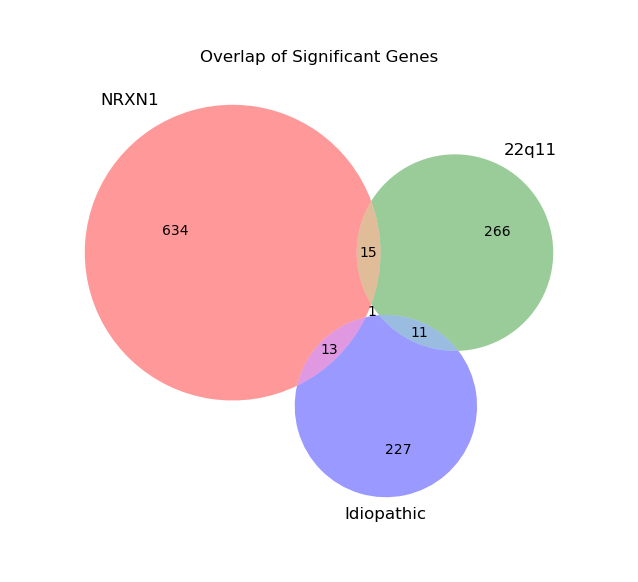

In [20]:
## Venn Diagram Of Overlap CellType Agonstic ##

# Convert your lists to sets
dge_nrxn1_set = set(dc_significant_nrxn1_df_logfc['ID'])
dge_22q11_set = set(dc_significant_22q11_df_logfc['ID'])
dge_idiopathic_set = set(dc_significant_idiopathic_df_logfc['ID'])

# --- Venn diagram for all three lists ---
plt.figure(figsize=(8, 6))
venn3([dge_nrxn1_set, dge_22q11_set, dge_idiopathic_set],
      set_labels=('NRXN1', '22q11', 'Idiopathic'))
plt.title("Overlap of Significant Genes")
plt.show()

In [21]:
dge_22q11_set.intersection(dge_idiopathic_set).intersection(dge_nrxn1_set) #.intersection(dge_3q29)

{'WWC2'}

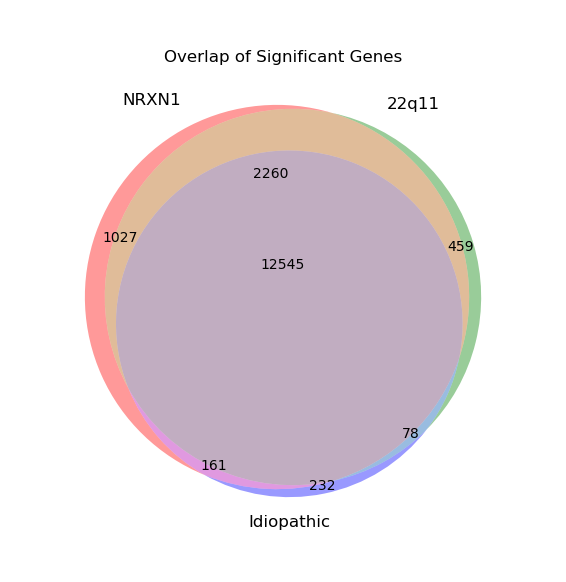

In [22]:
## Venn Diagram Of Overlap CellType Agonstic ##

## No Directional Consistency Demands ##

# --- Venn diagram for all three lists ---
plt.figure(figsize=(8, 6))
venn3([set(dge_nrxn1['ID']), set(dge_22q11['ID']), set(dge_idiopathic['ID'])],
      set_labels=('NRXN1', '22q11', 'Idiopathic'))
plt.title("Overlap of Significant Genes")
plt.show()

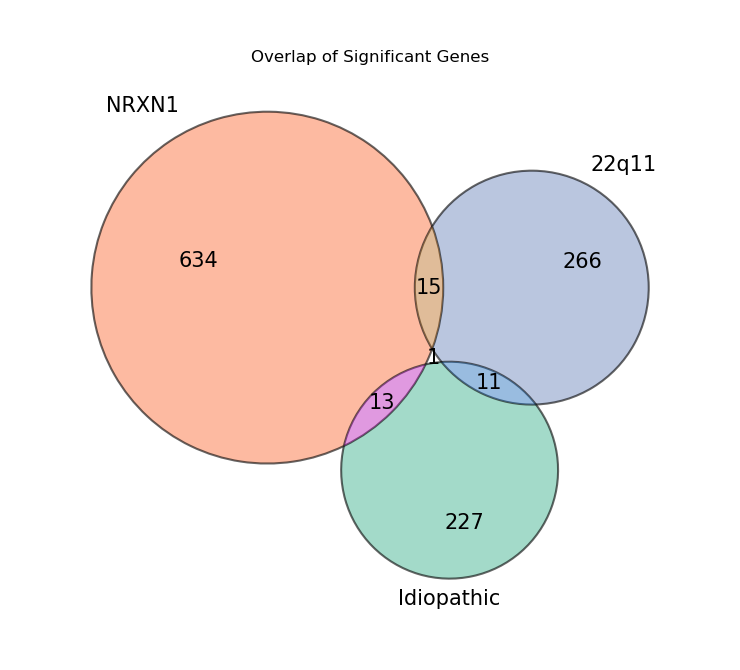

In [23]:
# # Convert to sets
dge_nrxn1_set = set(dc_significant_nrxn1_df_logfc['ID'])
dge_22q11_set = set(dc_significant_22q11_df_logfc['ID'])
dge_idiopathic_set = set(dc_significant_idiopathic_df_logfc['ID'])

# Custom colors
COLORS = {
    "NRXN1": "#fc8d62ff",
    "22q11": "#8da0cbff",
    "Idiopathic": "#66c2a5ff"
}
   
    
plt.figure(figsize=(8, 6))

v = venn3(
    [dge_nrxn1_set, dge_22q11_set, dge_idiopathic_set],
    set_labels=('NRXN1', '22q11', 'Idiopathic')
)

# MAIN SET COLORS + EDGES
v.get_patch_by_id('100').set_color(COLORS["NRXN1"])
v.get_patch_by_id('100').set_alpha(0.6)
v.get_patch_by_id('100').set_edgecolor('black')
v.get_patch_by_id('100').set_linewidth(1.5)

v.get_patch_by_id('010').set_color(COLORS["22q11"])
v.get_patch_by_id('010').set_alpha(0.6)
v.get_patch_by_id('010').set_edgecolor('black')
v.get_patch_by_id('010').set_linewidth(1.5)

v.get_patch_by_id('001').set_color(COLORS["Idiopathic"])
v.get_patch_by_id('001').set_alpha(0.6)
v.get_patch_by_id('001').set_edgecolor('black')
v.get_patch_by_id('001').set_linewidth(1.5)

# LABEL STYLING

for text in v.set_labels:
    if text:
        text.set_fontsize(15)

for text in v.subset_labels:
    if text:
        text.set_fontsize(15)

plt.title("Overlap of Significant Genes")
plt.tight_layout()
plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_all_celltypes_venn.svg", bbox_inches='tight')
plt.show()

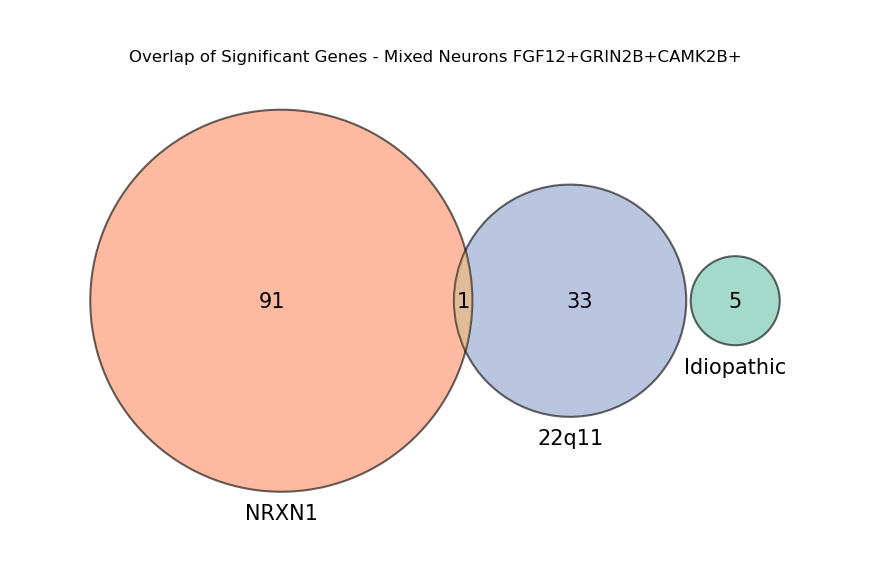

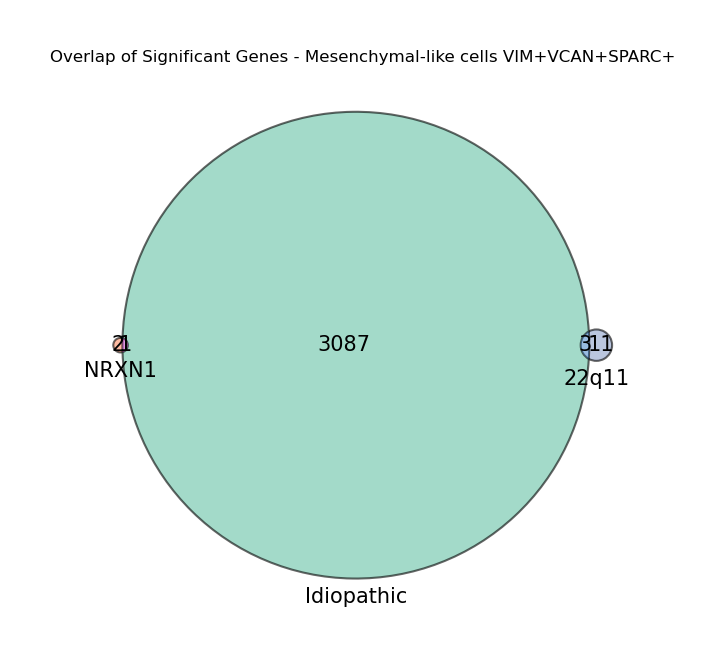

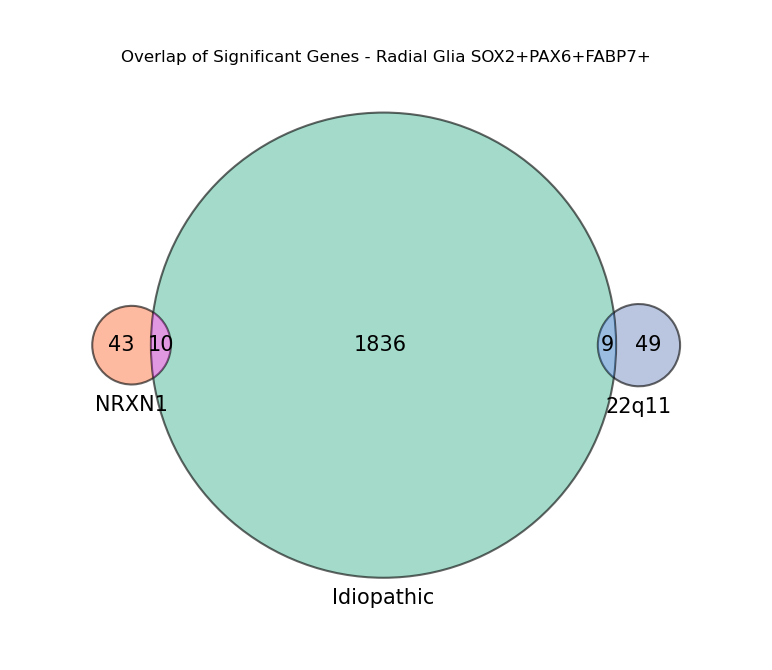

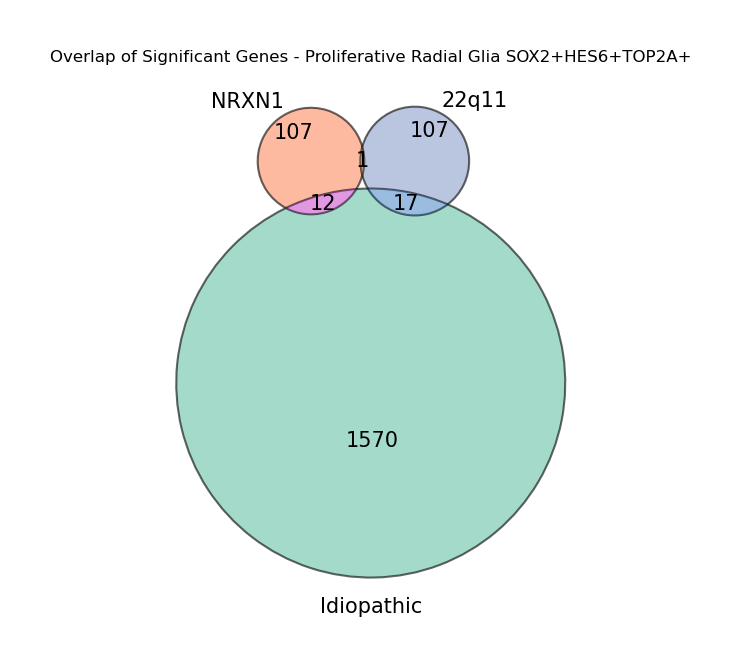

/home/deepak/pixi_envs/scanpy/.pixi/envs/default/lib/python3.12/site-packages/matplotlib_venn/layout/venn3/pairwise.py:103: UserWarning: Circle A has zero area.
  warnings.warn("Circle A has zero area.")
/home/deepak/pixi_envs/scanpy/.pixi/envs/default/lib/python3.12/site-packages/matplotlib_venn/layout/venn3/pairwise.py:111: UserWarning: Circle C has zero area.
  warnings.warn("Circle C has zero area.")


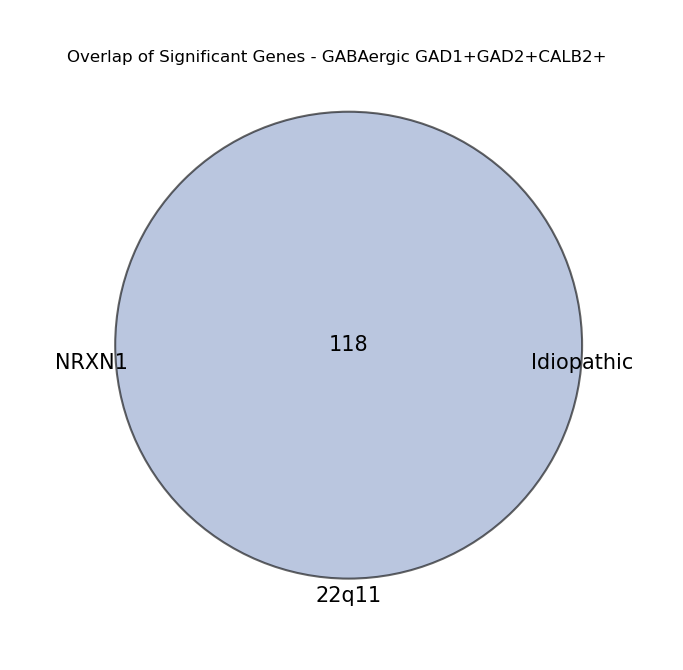

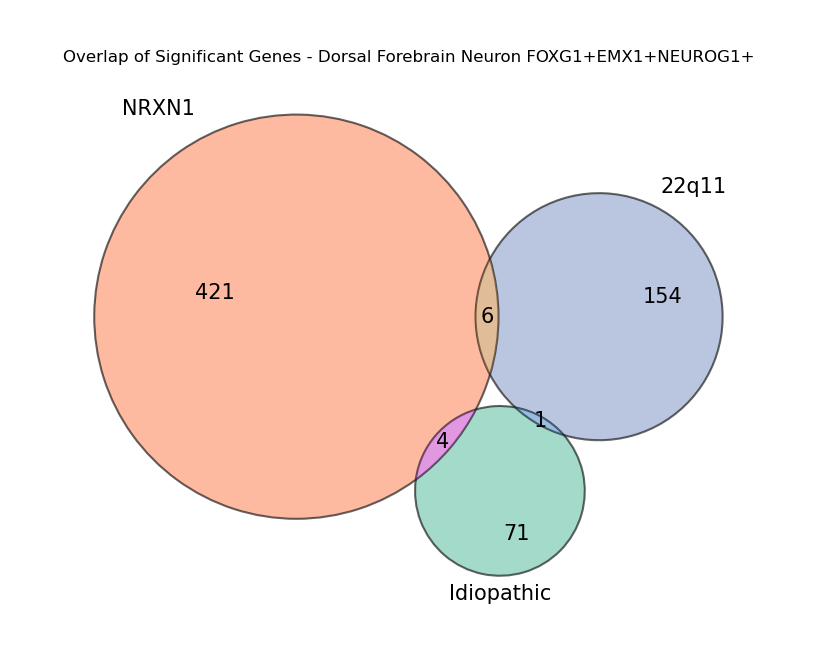

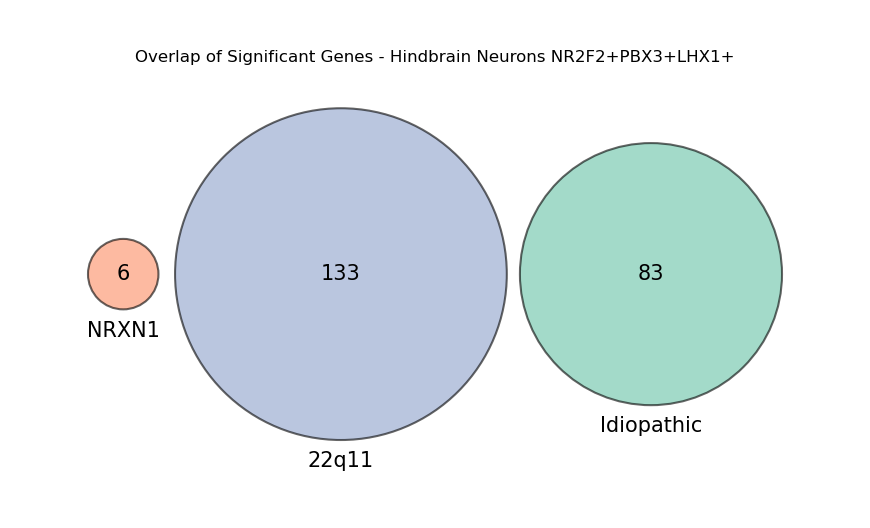

/home/deepak/pixi_envs/scanpy/.pixi/envs/default/lib/python3.12/site-packages/matplotlib_venn/layout/venn3/pairwise.py:107: UserWarning: Circle B has zero area.
  warnings.warn("Circle B has zero area.")


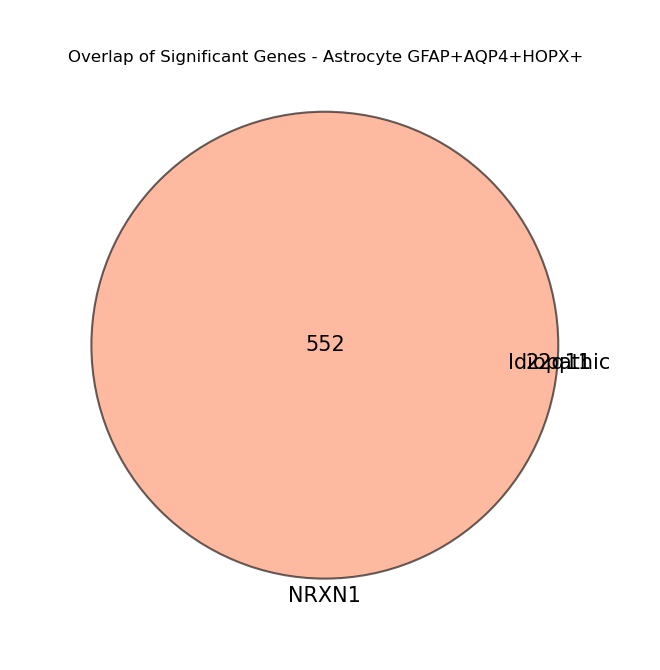

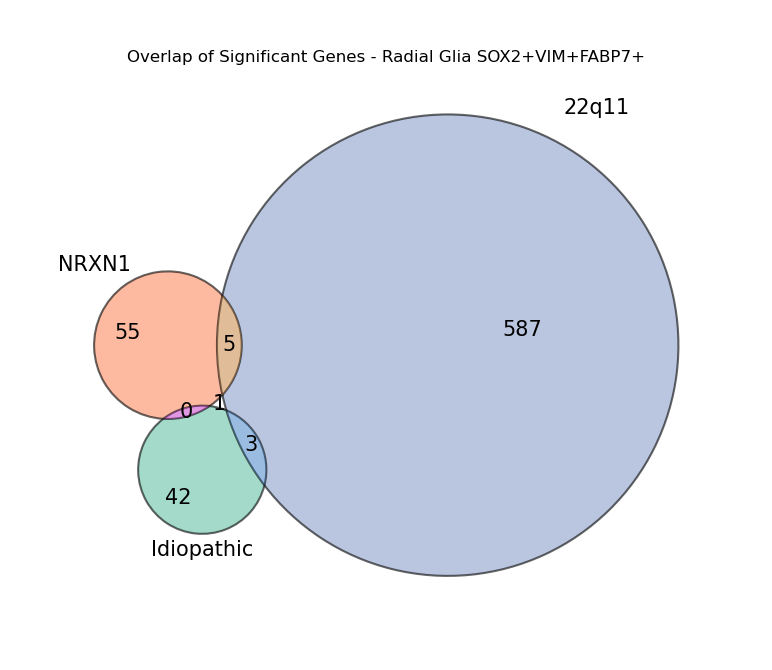

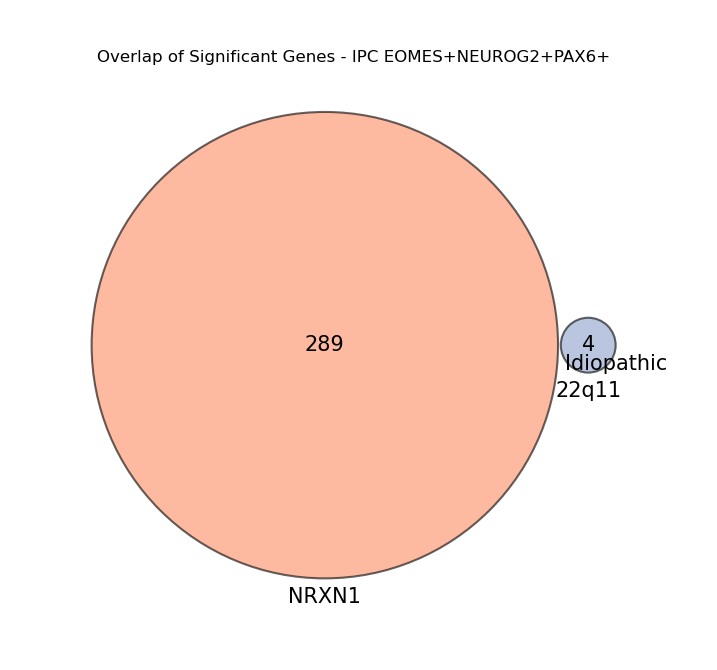

In [25]:
# Convert to sets

celltypes = set(dge_idiopathic['assay']).union(set(dge_22q11['assay'])).union(set(dge_nrxn1['assay']))

# Custom colors
COLORS = {"NRXN1": "#fc8d62ff", "22q11": "#8da0cbff", "Idiopathic": "#66c2a5ff"}
def safe_style_patch(v, pid, color):
    patch = v.get_patch_by_id(pid)
    if patch is not None:
        patch.set_color(color)
        patch.set_alpha(0.6)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.5)

# -----------------------------
# LOOP OVER CELLTYPES
# -----------------------------
for celltype in celltypes:

    idiopathic_filter = set(
        dge_idiopathic[(dge_idiopathic['assay'] == celltype) & dge_idiopathic['significant_fdr']]['ID']
    )
    x22q11_filter = set(
        dge_22q11[(dge_22q11['assay'] == celltype) & dge_22q11['significant_fdr']]['ID']
    )
    nrxn1_filter = set(
        dge_nrxn1[(dge_nrxn1['assay'] == celltype) & dge_nrxn1['significant_fdr']]['ID']
    )

    plt.figure(figsize=(8, 6))

    v = venn3(
        [nrxn1_filter, x22q11_filter, idiopathic_filter],
        set_labels=('NRXN1', '22q11', 'Idiopathic')
    )

    # -----------------------------
    # STYLE SET REGIONS SAFELY
    # -----------------------------
    safe_style_patch(v, '100', COLORS["NRXN1"])
    safe_style_patch(v, '010', COLORS["22q11"])
    safe_style_patch(v, '001', COLORS["Idiopathic"])

    # -----------------------------
    # STYLE LABELS SAFELY
    # -----------------------------
    if v.set_labels:
        for text in v.set_labels:
            if text:
                text.set_fontsize(15)

    if v.subset_labels:
        for text in v.subset_labels:
            if text:
                text.set_fontsize(15)

    plt.title(f"Overlap of Significant Genes - {celltype}")
    plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_{celltype}_venn.svg", bbox_inches='tight')
    plt.tight_layout()
    plt.show()

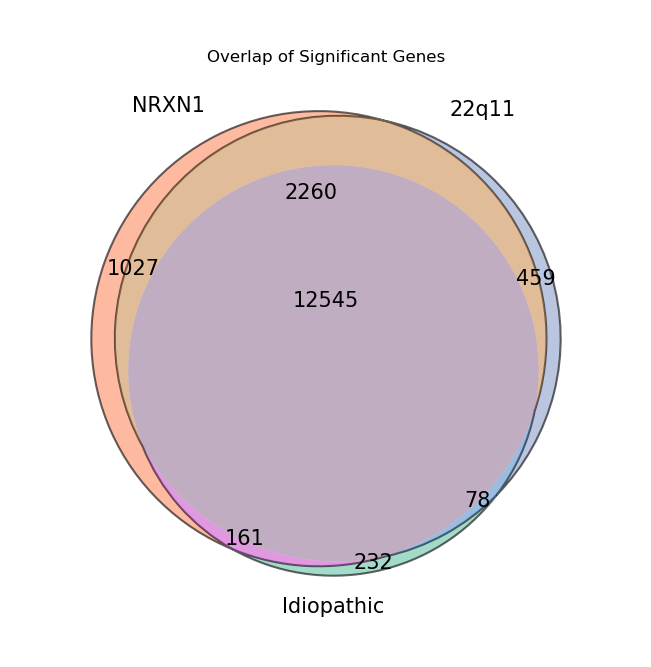

In [26]:
## Without DC ##

dge_nrxn1_set = set(dge_nrxn1['ID'])
dge_22q11_set = set(dge_22q11['ID'])
dge_idiopathic_set = set(dge_idiopathic['ID'])

# Custom colors
COLORS = {
    "NRXN1": "#fc8d62ff",
    "22q11": "#8da0cbff",
    "Idiopathic": "#66c2a5ff"
}

plt.figure(figsize=(8, 6))

v = venn3(
    [dge_nrxn1_set, dge_22q11_set, dge_idiopathic_set],
    set_labels=('NRXN1', '22q11', 'Idiopathic')
)

# =====================================================
# MAIN SET COLORS + EDGES
# =====================================================

v.get_patch_by_id('100').set_color(COLORS["NRXN1"])
v.get_patch_by_id('100').set_alpha(0.6)
v.get_patch_by_id('100').set_edgecolor('black')
v.get_patch_by_id('100').set_linewidth(1.5)

v.get_patch_by_id('010').set_color(COLORS["22q11"])
v.get_patch_by_id('010').set_alpha(0.6)
v.get_patch_by_id('010').set_edgecolor('black')
v.get_patch_by_id('010').set_linewidth(1.5)

v.get_patch_by_id('001').set_color(COLORS["Idiopathic"])
v.get_patch_by_id('001').set_alpha(0.6)
v.get_patch_by_id('001').set_edgecolor('black')
v.get_patch_by_id('001').set_linewidth(1.5)

# =====================================================
# LABEL STYLING (optional polish)
# =====================================================

for text in v.set_labels:
    if text:
        text.set_fontsize(15)

for text in v.subset_labels:
    if text:
        text.set_fontsize(15)

plt.title("Overlap of Significant Genes")
plt.tight_layout()
plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_all_celltypes_venn.svg", bbox_inches='tight')
plt.show()

In [27]:
## Identify Genes Across Disease That May Not be Directionally Consistent Within a Disease, but Significant Within and Across Dx ##

df_22q11_non_dc_to_merge = significant_22q11_df_logfc.copy()
df_22q11_non_dc_to_merge.columns = [i+'_22q11' for i in df_22q11_non_dc_to_merge.columns]

df_nrxn1_non_dc_to_merge = significant_nrnx1_df_logfc.copy()
df_nrxn1_non_dc_to_merge.columns = [i+'_nrxn1' for i in df_nrxn1_non_dc_to_merge.columns]

df_idiopathic_non_dc_to_merge = significant_idiopathic_df_logfc.copy()
df_idiopathic_non_dc_to_merge.columns = [i+'_idiopathic' for i in df_idiopathic_non_dc_to_merge.columns]

df_22q11_nrxn1_non_dc = df_22q11_non_dc_to_merge.merge(df_nrxn1_non_dc_to_merge, 
                                         right_on=['ID_nrxn1', 'assay_nrxn1'], 
                                         left_on=['ID_22q11', 'assay_22q11'])

df_22q11_idiopathic_non_dc = df_22q11_non_dc_to_merge.merge(df_idiopathic_non_dc_to_merge, 
                                              right_on=['ID_idiopathic', 'assay_idiopathic'], 
                                              left_on=['ID_22q11', 'assay_22q11'])

df_nrxn1_idiopathic_non_dc = df_nrxn1_non_dc_to_merge.merge(df_idiopathic_non_dc_to_merge, 
                                              right_on=['ID_idiopathic', 'assay_idiopathic'], 
                                              left_on=['ID_nrxn1', 'assay_nrxn1'])

In [28]:
df_22q11_nrxn1_non_dc[[i for i in df_22q11_nrxn1_non_dc.columns if ('logFC' in i) or ('ID' in i)]]

## if you lax the constraints to take things thta dont have full directional consistency, you can get a few extra hits ##
## one of which has NRXN1 22q11.2 deletion mixup ## Nothing Shared with Idiopathic ##

,ID_22q11,assay_ID_22q11,logFC_rao_22q11,logFC_shin_22q11,logFC_walsh_22q11,mean_logFC_22q11,ID_nrxn1,assay_ID_nrxn1,logFC_sebastian_nrxn1,logFC_fernando_nrxn1,mean_logFC_nrxn1
0,ESS2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.931210,-0.482282,-0.962693,-0.792062,ESS2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.117488,0.517913,0.317700
1,GOLGA8B,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.771310,-0.019227,1.023847,0.591977,GOLGA8B,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.251183,-1.051003,-0.399910
2,PDGFD,Radial Glia SOX2+VIM+FABP7+ | PDGFD,0.810287,0.751816,0.082459,0.548187,PDGFD,Radial Glia SOX2+VIM+FABP7+ | PDGFD,0.163255,-1.800072,-0.818409
3,PIM1,Radial Glia SOX2+VIM+FABP7+ | PIM1,-0.573554,-1.385680,-0.540774,-0.833336,PIM1,Radial Glia SOX2+VIM+FABP7+ | PIM1,0.214780,1.481326,0.848053


In [29]:
## What if it was enough that a single gene was showing up in multiple different disease in the same direction ideally ##

sig_22q11_idiopathic_set = set(dc_significant_22q11_df_logfc['ID']).intersection(dc_significant_idiopathic_df_logfc['ID'])

sig_22q11_nrxn1_set = set(dc_significant_22q11_df_logfc['ID']).intersection(dc_significant_nrxn1_df_logfc['ID'])

sig_idiopathic_nrxn1_set = set(dc_significant_idiopathic_df_logfc['ID']).intersection(dc_significant_nrxn1_df_logfc['ID'])

In [30]:
dc_significant_all = pd.concat([dc_significant_idiopathic_df_logfc.assign(group='Idiopathic Schizophrenia'),
                                dc_significant_nrxn1_df_logfc.assign(group='NRXN1del'), 
                                dc_significant_22q11_df_logfc.assign(group='22q11.2del')], axis=0)

In [31]:
significant_all = pd.concat([dge_idiopathic.assign(group='Idiopathic Schizophrenia'),
                                dge_nrxn1.assign(group='NRXN1del'), 
                                dge_22q11.assign(group='22q11.2del')], axis=0)

significant_all = significant_all[significant_all['significant_fdr']]

In [32]:
dge_3q29['significant_fdr'] = (dge_3q29['adj.P.Val'] < 0.05)

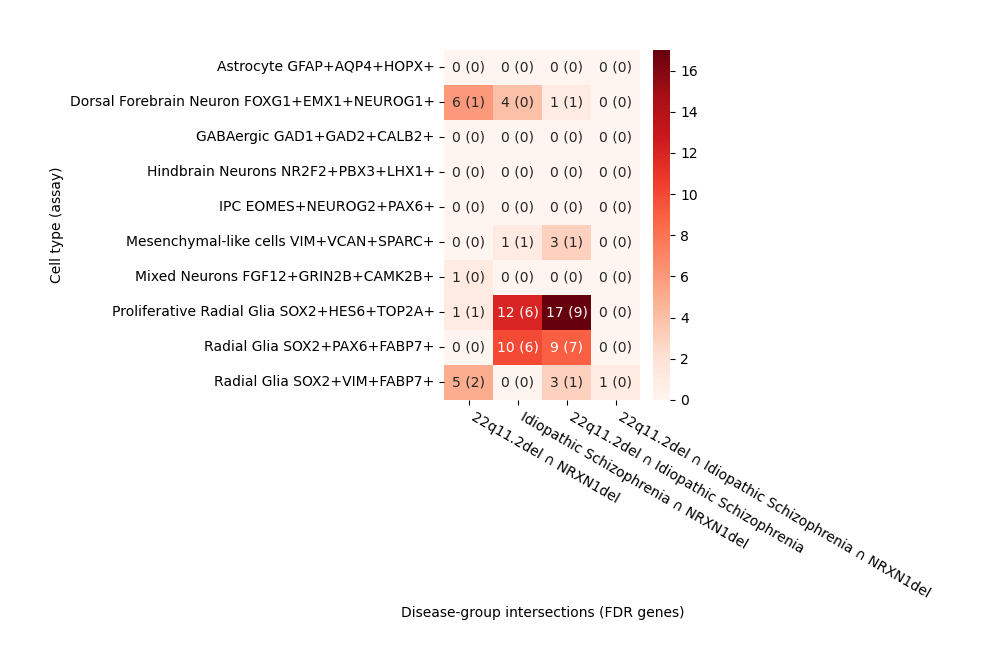

In [33]:
## Generate Counts Heatmap 3#

df = significant_all.copy()
df = df[df["significant_fdr"]]

# -------------------------------------------------------
# 1. gene → group set within assay
# -------------------------------------------------------
gene_group_map = (
    df.groupby(["assay", "ID"])["group"]
      .apply(lambda x: frozenset(x.unique()))
      .reset_index(name="group_set")
)

def label(gs):
    gs = tuple(sorted(gs))
    if len(gs) == 1:
        return gs[0]
    return " ∩ ".join(gs)

gene_group_map["intersection"] = gene_group_map["group_set"].apply(label)

# -------------------------------------------------------
# 2. attach estimates to detect direction
# -------------------------------------------------------
gene_estimate = (
    df.groupby(["assay", "ID"])["estimate"]
      .apply(list)
      .reset_index(name="estimates")
)

gene_group_map = gene_group_map.merge(
    gene_estimate,
    on=["assay", "ID"],
    how="left"
)

# -------------------------------------------------------
# 3. direction consistency (same sign across all rows)
# -------------------------------------------------------
def direction_agree(vals):
    vals = [v for v in vals if pd.notnull(v)]
    if len(vals) == 0:
        return 0
    return int(all(v > 0 for v in vals) or all(v < 0 for v in vals))

gene_group_map["direction_ok"] = gene_group_map["estimates"].apply(direction_agree)

# -------------------------------------------------------
# 4. build counts + directional counts
# -------------------------------------------------------
count_mat = pd.crosstab(
    gene_group_map["assay"],
    gene_group_map["intersection"]
)

dir_mat = gene_group_map.groupby(["assay", "intersection"])["direction_ok"].sum().unstack(fill_value=0)

# keep only intersections (no "only")
cols = [c for c in count_mat.columns if "∩" in c]
count_mat = count_mat[cols]
dir_mat = dir_mat.reindex(columns=cols, fill_value=0)

# -------------------------------------------------------
# 5. build annotation "x (y)"
# -------------------------------------------------------
annot = count_mat.astype(str) + " (" + dir_mat.astype(str) + ")"

# -------------------------------------------------------
# 6. plot
# -------------------------------------------------------
plt.figure(figsize=(8,6))
sns.heatmap(
    count_mat[['22q11.2del ∩ NRXN1del',
               'Idiopathic Schizophrenia ∩ NRXN1del', 
               '22q11.2del ∩ Idiopathic Schizophrenia', 
               '22q11.2del ∩ Idiopathic Schizophrenia ∩ NRXN1del']],
    cmap="Reds",
    annot=annot[['22q11.2del ∩ NRXN1del',
               'Idiopathic Schizophrenia ∩ NRXN1del', 
               '22q11.2del ∩ Idiopathic Schizophrenia', 
               '22q11.2del ∩ Idiopathic Schizophrenia ∩ NRXN1del']],
    fmt="",
    cbar=True
)

plt.xlabel("Disease-group intersections (FDR genes)")
plt.xticks(rotation=-30, ha='left')
plt.ylabel("Cell type (assay)")
plt.tight_layout()
plt.show()

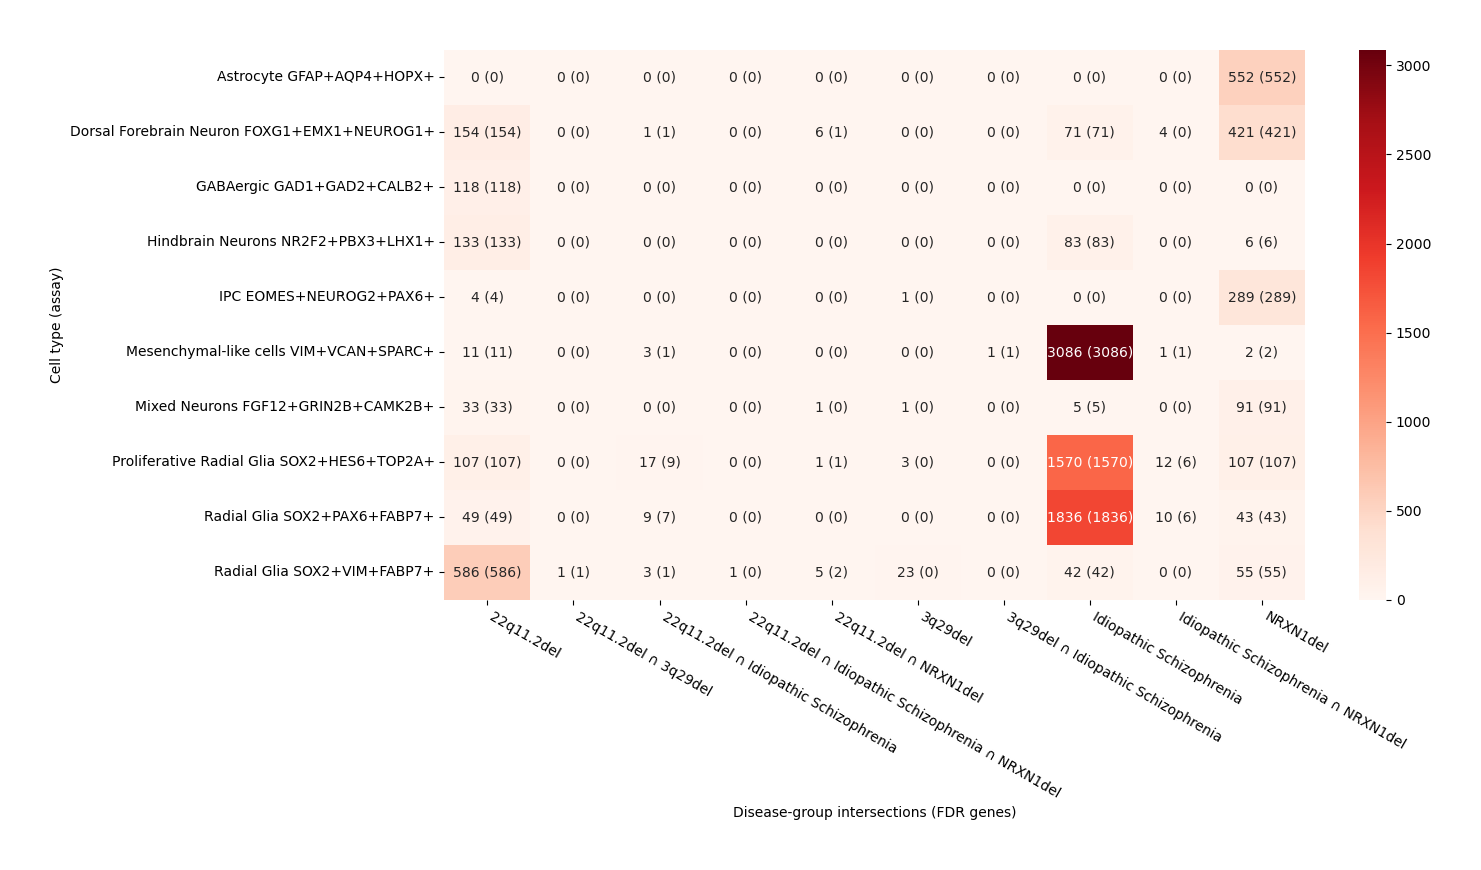

In [34]:
significant_all = pd.concat([dge_idiopathic.assign(group='Idiopathic Schizophrenia'),
                                dge_nrxn1.assign(group='NRXN1del'), 
                                dge_22q11.assign(group='22q11.2del'),
                                dge_3q29.assign(group='3q29del')], axis=0)

significant_all = significant_all[significant_all['significant_fdr']]

df = significant_all.copy()
df = df[df["significant_fdr"]]

# -------------------------------------------------------
# 1. BUILD GENE → GROUP SET
# -------------------------------------------------------
gene_group_map = (
    df.groupby(["assay", "ID"])["group"]
      .apply(lambda x: frozenset(x.unique()))
      .reset_index(name="group_set")
)

# -------------------------------------------------------
# LABEL INTERSECTIONS (NOW INCLUDES 4-WAY)
# -------------------------------------------------------
def label(gs):
    gs = tuple(sorted(gs))
    if len(gs) == 1:
        return gs[0]
    return " ∩ ".join(gs)

gene_group_map["intersection"] = gene_group_map["group_set"].apply(label)

# -------------------------------------------------------
# 2. ATTACH EFFECT ESTIMATES
# -------------------------------------------------------
gene_estimate = (
    df.groupby(["assay", "ID"])["estimate"]
      .apply(list)
      .reset_index(name="estimates")
)

gene_group_map = gene_group_map.merge(
    gene_estimate,
    on=["assay", "ID"],
    how="left"
)

# -------------------------------------------------------
# 3. DIRECTION CONSISTENCY
# -------------------------------------------------------
def direction_agree(vals):
    vals = [v for v in vals if pd.notnull(v)]
    if len(vals) == 0:
        return 0
    return int(all(v > 0 for v in vals) or all(v < 0 for v in vals))

gene_group_map["direction_ok"] = gene_group_map["estimates"].apply(direction_agree)

# -------------------------------------------------------
# 4. BUILD MATRICES (DO NOT FILTER COLUMNS YET)
# -------------------------------------------------------
count_mat = pd.crosstab(
    gene_group_map["assay"],
    gene_group_map["intersection"]
)

dir_mat = (
    gene_group_map
    .groupby(["assay", "intersection"])["direction_ok"]
    .sum()
    .unstack(fill_value=0)
)

# align matrices
dir_mat = dir_mat.reindex_like(count_mat).fillna(0)

# -------------------------------------------------------
# 5. OPTIONAL: SORT COLUMNS (keeps all intersections incl. 4-way)
# -------------------------------------------------------
count_mat = count_mat.loc[:, sorted(count_mat.columns)]
dir_mat = dir_mat.loc[:, count_mat.columns]

# -------------------------------------------------------
# 6. ANNOTATION (COUNT + DIRECTION)
# -------------------------------------------------------
annot = count_mat.astype(str) + " (" + dir_mat.astype(int).astype(str) + ")"

# -------------------------------------------------------
# 7. PLOT
# -------------------------------------------------------
plt.figure(figsize=(15, 8))

sns.heatmap(
    count_mat,
    cmap="Reds",
    annot=annot,
    fmt="",
    cbar=True
)

plt.xlabel("Disease-group intersections (FDR genes)")
plt.ylabel("Cell type (assay)")
plt.xticks(rotation=-30, ha='left')
plt.tight_layout()
plt.show()

In [35]:
df[df['assay'] == 'Radial Glia SOX2+VIM+FABP7+']['ID'].value_counts()[df[df['assay'] == 'Radial Glia SOX2+VIM+FABP7+']['ID'].value_counts() == 3]

ID
PIM1    3
Name: count, dtype: int64

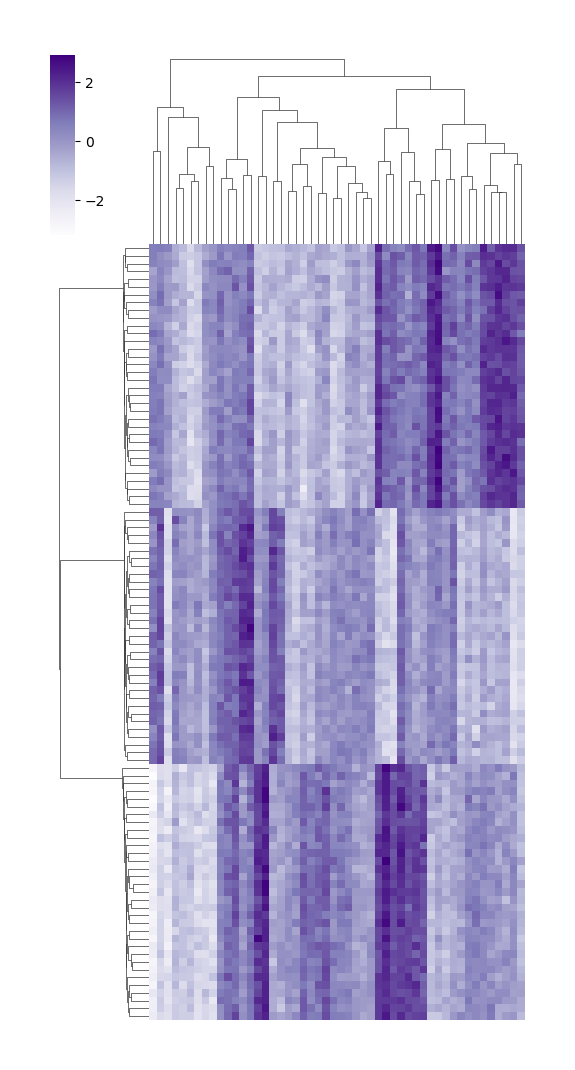

In [67]:
np.random.seed(0)

n_genes = 100
n_samples = 50

# create 3 latent signals (3 blocks)
block1 = np.random.randn(n_samples)
block2 = np.random.randn(n_samples)
block3 = np.random.randn(n_samples)

data = np.zeros((n_genes, n_samples))

data[0:33]   = block1 + 0.3 * np.random.randn(33, n_samples)
data[33:66]  = block2 + 0.3 * np.random.randn(33, n_samples)
data[66:100] = block3 + 0.3 * np.random.randn(34, n_samples)

df = pd.DataFrame(
    data,
    index=[f"gene_{i}" for i in range(n_genes)],
    columns=[f"cell_{i}" for i in range(n_samples)]
)

sns.clustermap(
    df,
    cmap="Purples",
    figsize=(5, 10),
    xticklabels=False,
    yticklabels=False
)

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_mashR_schematic.svg", bbox_inches='tight')
plt.show()

In [68]:
def plot_assay_upset(df, set_col='group', gene_col='ID', significance_col='significant_fdr', 
                     min_size=1, dataset_label="", top_graph=True, side_graph=True, title=True, 
                     save=False):

    # filter significant genes
    if significance_col in df.columns:
        df = df[df[significance_col] == True]
    
    assay_sets = {val: set(group[gene_col].dropna().unique())
        for val, group in df.groupby(set_col)}
    
    # remove small sets
    assay_sets = {k: v for k, v in assay_sets.items() if len(v) >= min_size}
    
    # safety check
    if len(assay_sets) < 2:
        print(f"Not enough groups to plot: {list(assay_sets.keys())}")
        return
    
    # convert
    upset_data = from_contents(assay_sets)
    
    plt.figure(figsize=(10, 6))

    if top_graph and side_graph:
        upset = UpSet(upset_data, show_counts=True, sort_by='degree')
    elif top_graph and not side_graph:
        upset = UpSet(upset_data, show_counts=True, with_lines=True, element_size=49, totals_plot_elements=0)
    elif side_graph and not top_graph:
        upset = UpSet(upset_data, show_counts=True, with_lines=True, element_size=49, intersection_plot_elements=())
    else:
        upset = UpSet(upset_data, show_counts=True, with_lines=True, element_size=49, intersection_plot_elements=(), totals_plot_elements=0)
    
    upset.plot()

    if title:
        plt.suptitle(f"{dataset_label} Shared DGEs")
        
    if save:
        plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_{dataset_label}_upset_.svg")
    
    plt.show()

In [69]:
dc_significant_all['group'].value_counts()

group
NRXN1del                    723
22q11.2del                  340
Idiopathic Schizophrenia    257
Name: count, dtype: int64

In [70]:
dc_significant_all_rg_pax6 = dc_significant_all[dc_significant_all['assay'] == 'Radial Glia SOX2+PAX6+FABP7+']
dc_significant_all_prg = dc_significant_all[dc_significant_all['assay'] == 'Proliferative Radial Glia SOX2+HES6+TOP2A+']
dc_significant_all_rg_vim = dc_significant_all[dc_significant_all['assay'] == 'Radial Glia SOX2+VIM+FABP7+']
dc_significant_all_ipc = dc_significant_all[dc_significant_all['assay'] == 'IPC EOMES+NEUROG2+PAX6+']
dc_significant_all_dorsal = dc_significant_all[dc_significant_all['assay'] == 'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+']
dc_significant_all_mixed = dc_significant_all[dc_significant_all['assay'] == 'Mixed Neurons FGF12+GRIN2B+CAMK2B+']
dc_significant_all_hindbrain = dc_significant_all[dc_significant_all['assay'] == 'Hindbrain Neurons NR2F2+PBX3+LHX1+']
dc_significant_all_mc = dc_significant_all[dc_significant_all['assay'] == 'Mesenchymal-like cells VIM+VCAN+SPARC+']
dc_significant_all_astro = dc_significant_all[dc_significant_all['assay'] == 'Astrocyte GFAP+AQP4+HOPX+']

In [71]:
significant_all_rg_pax6 = significant_all[significant_all['assay'] == 'Radial Glia SOX2+PAX6+FABP7+']
significant_all_prg = significant_all[significant_all['assay'] == 'Proliferative Radial Glia SOX2+HES6+TOP2A+']
significant_all_rg_vim = significant_all[significant_all['assay'] == 'Radial Glia SOX2+VIM+FABP7+']
significant_all_ipc = significant_all[significant_all['assay'] == 'IPC EOMES+NEUROG2+PAX6+']
significant_all_dorsal = significant_all[significant_all['assay'] == 'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+']
significant_all_mixed = significant_all[significant_all['assay'] == 'Mixed Neurons FGF12+GRIN2B+CAMK2B+']
significant_all_hindbrain = significant_all[significant_all['assay'] == 'Hindbrain Neurons NR2F2+PBX3+LHX1+']
significant_all_mc = significant_all[significant_all['assay'] == 'Mesenchymal-like cells VIM+VCAN+SPARC+']
significant_all_astro = significant_all[significant_all['assay'] == 'Astrocyte GFAP+AQP4+HOPX+']
significant_all_gaba = significant_all[significant_all['assay'] == 'GABAergic GAD1+GAD2+CALB2+']

<Figure size 1000x600 with 0 Axes>

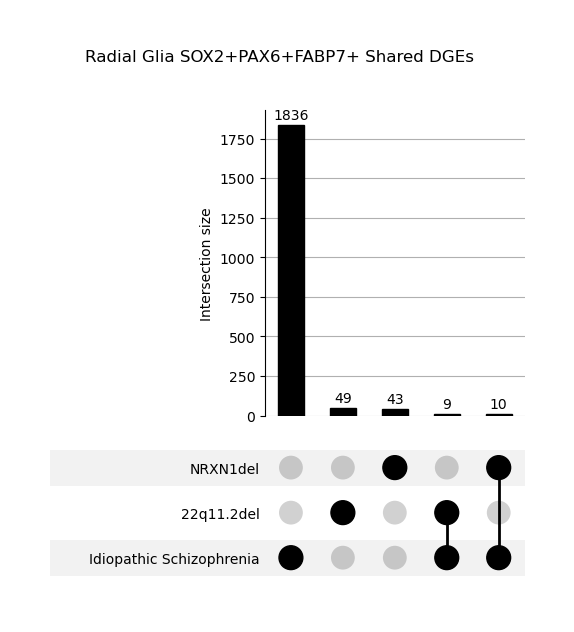

In [72]:
plot_assay_upset(significant_all_rg_pax6,  dataset_label="Radial Glia SOX2+PAX6+FABP7+", 
                 set_col='group', top_graph=True, side_graph=False, save=True)

<Figure size 1000x600 with 0 Axes>

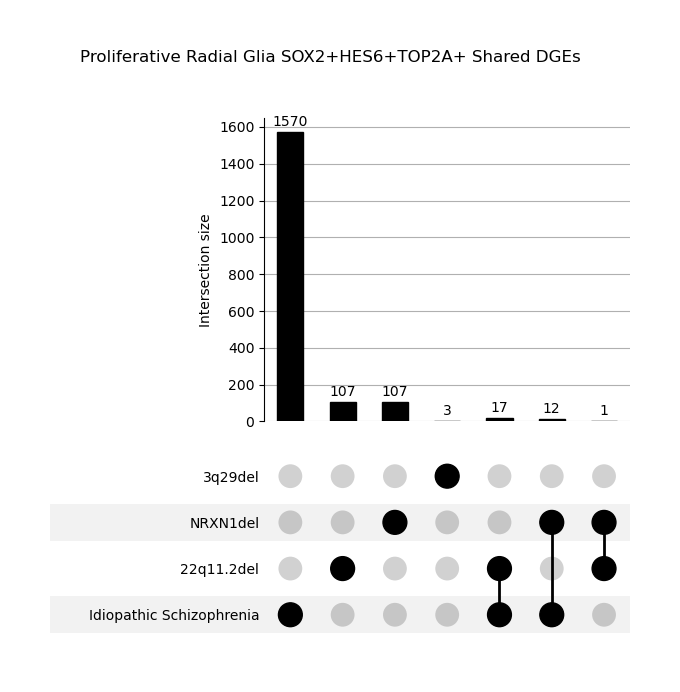

In [73]:
plot_assay_upset(significant_all_prg, dataset_label="Proliferative Radial Glia SOX2+HES6+TOP2A+", 
                 set_col='group', top_graph=True, side_graph=False, save=True)

<Figure size 1000x600 with 0 Axes>

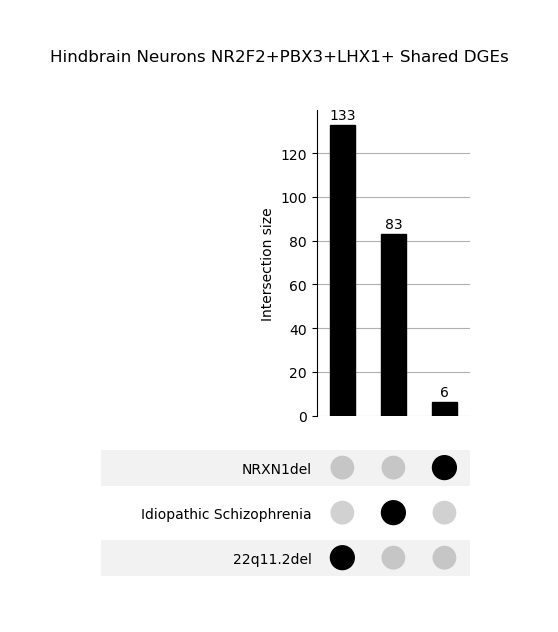

In [74]:
plot_assay_upset(significant_all_hindbrain, dataset_label="Hindbrain Neurons NR2F2+PBX3+LHX1+",
                 set_col='group', top_graph=True, side_graph=False, save=True)

<Figure size 1000x600 with 0 Axes>

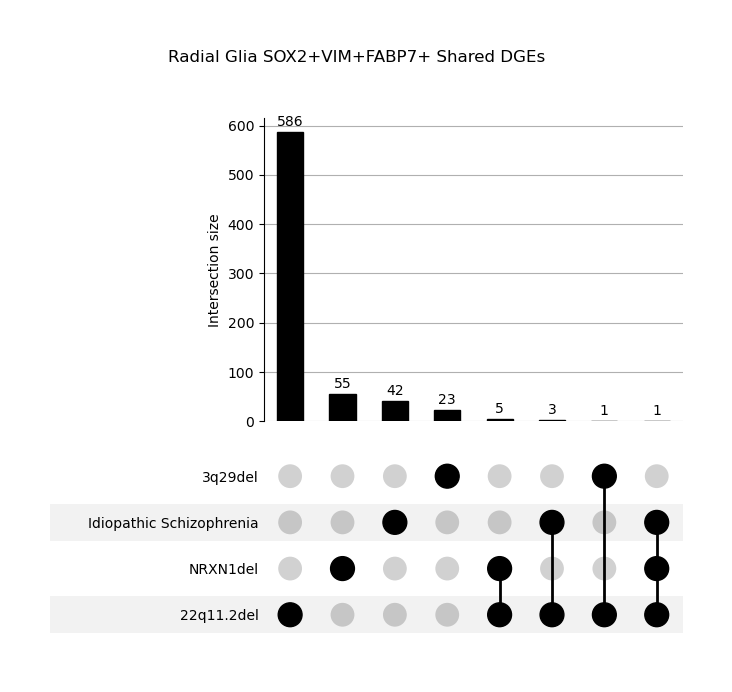

In [75]:
plot_assay_upset(significant_all_rg_vim, dataset_label="Radial Glia SOX2+VIM+FABP7+", set_col='group',
                 top_graph=True, side_graph=False, save=True)

<Figure size 1000x600 with 0 Axes>

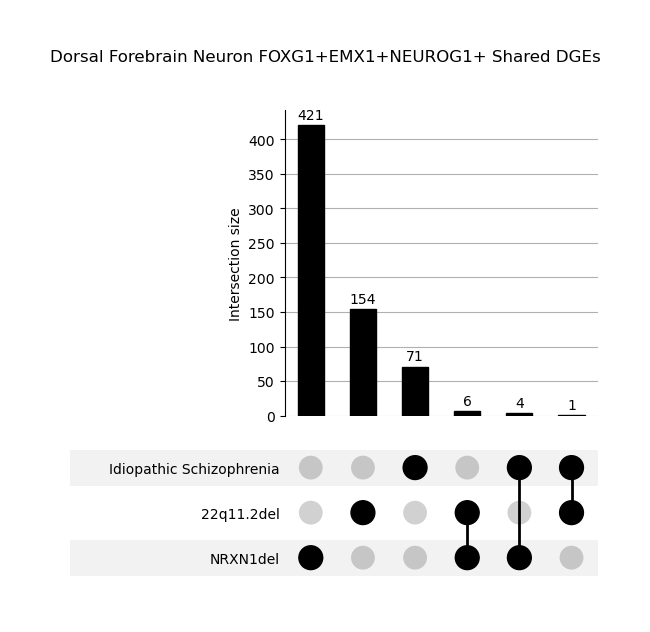

In [76]:
plot_assay_upset(significant_all_dorsal, dataset_label="Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+",
                 set_col='group', top_graph=True, side_graph=False, save=True)

<Figure size 1000x600 with 0 Axes>

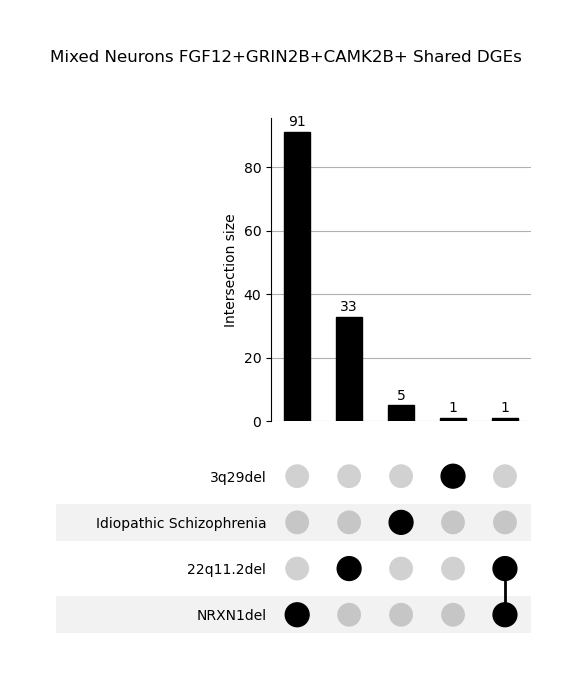

In [77]:
plot_assay_upset(significant_all_mixed, dataset_label="Mixed Neurons FGF12+GRIN2B+CAMK2B+",  
                 set_col='group', top_graph=True, side_graph=False, save=True)

In [78]:
plot_assay_upset(significant_all_astro, dataset_label="Astrocyte",  
                 set_col='group', top_graph=True, side_graph=False, save=True)

Not enough groups to plot: ['NRXN1del']


<Figure size 1000x600 with 0 Axes>

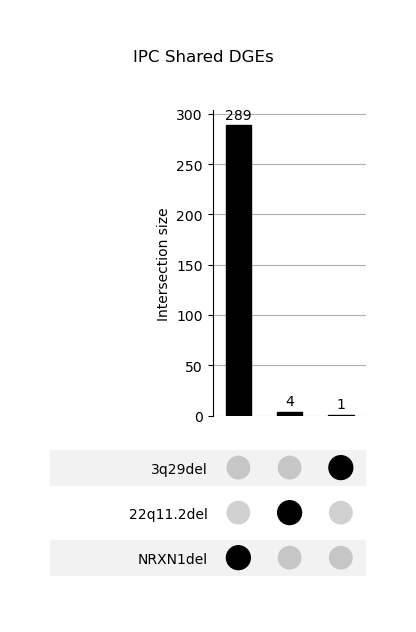

In [79]:
plot_assay_upset(significant_all_ipc, dataset_label="IPC",  
                 set_col='group', top_graph=True, side_graph=False, save=True)

<Figure size 1000x600 with 0 Axes>

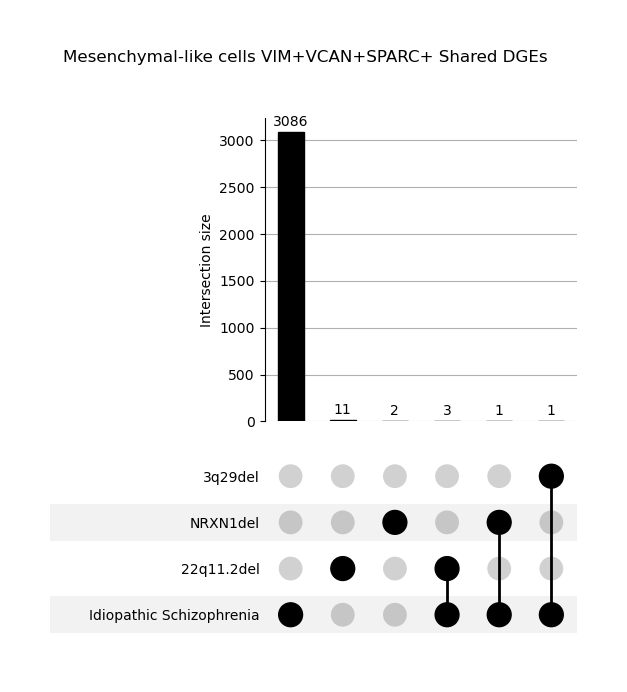

In [80]:
plot_assay_upset(significant_all_mc, dataset_label="Mesenchymal-like cells VIM+VCAN+SPARC+",  
                 set_col='group', top_graph=True, side_graph=False, save=True)

In [81]:
plot_assay_upset(significant_all_gaba, dataset_label="GABA",  
                 set_col='group', top_graph=True, side_graph=False, save=True)

Not enough groups to plot: ['22q11.2del']


In [82]:
## Import Posterior Tests from mashR ##

dfn_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Dorsal_Forebrain_Neuron_FOXG1+EMX1+NEUROG1+_all.csv')
rg_vim_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Radial_Glia_SOX2+VIM+FABP7+_all.csv')
rg_pax_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Radial_Glia_SOX2+PAX6+FABP7+_all.csv')
mc_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Mesenchymal-like_cells_VIM+VCAN+SPARC+_all.csv')
gaba_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_GABAergic_GAD1+GAD2+CALB2+_all.csv')
prg_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Proliferative_Radial_Glia_SOX2+HES6+TOP2A+_all.csv')
ipc_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_IPC_EOMES+NEUROG2+PAX6+_all.csv')
mn_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Mixed_Neurons_FGF12+GRIN2B+CAMK2B+_all.csv')
astro_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Astrocyte_GFAP+AQP4+HOPX+_all.csv')

In [83]:
idiopathic_sig = significant_all[significant_all['group'] == 'Idiopathic Schizophrenia']
x22q11_sig = significant_all[significant_all['group'] == '22q11.2del']
nrxn1_sig = significant_all[significant_all['group'] == 'NRXN1del']

In [84]:
combined = pd.DataFrame({
    "gene": dfn_composite["gene"],
    "score_dfn": dfn_composite["score"],
    "score_rg_vim": rg_vim_composite["score"],
    "score_rg_pax": rg_pax_composite["score"],
    "score_mc": mc_composite["score"],
    "score_gaba": gaba_composite["score"],
    "score_prg": prg_composite["score"],
    "score_ipc": ipc_composite["score"],
    "score_mn": mn_composite["score"],
    "score_astro": astro_composite["score"],
})

combined = combined.set_index("gene")

combined.to_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/combined_composite_test.csv')

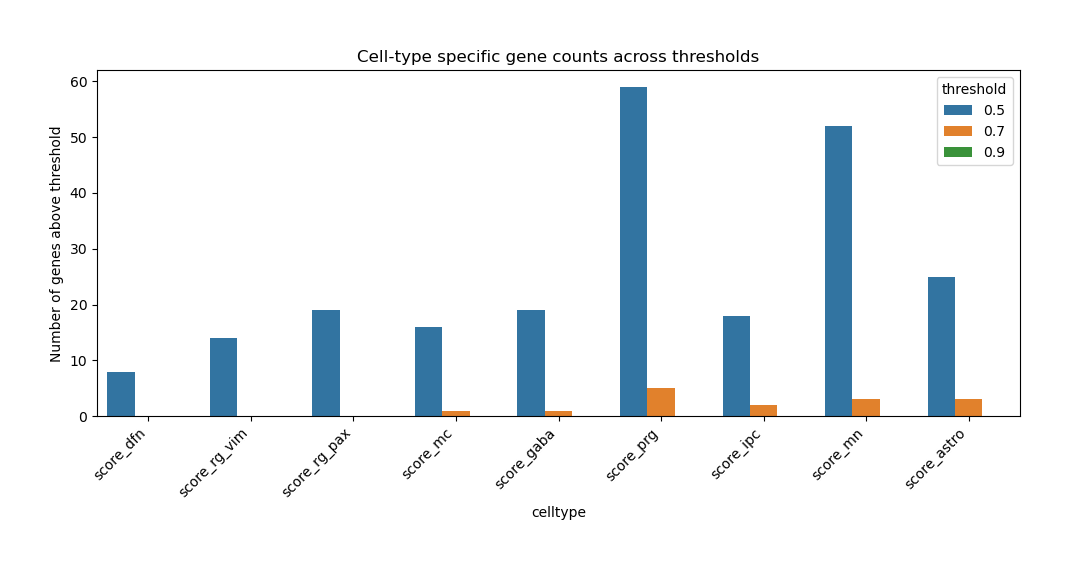

In [86]:
thresholds = [0.5, 0.7, 0.9]

data = []

for t in thresholds:
    counts = (combined > t).sum(axis=0)  # per cell type
    for celltype, value in counts.items():
        data.append({
            "celltype": celltype,
            "threshold": str(t),
            "count": value
        })

df = pd.DataFrame(data)


plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="celltype",
    y="count",
    hue="threshold"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of genes above threshold")
plt.title("Cell-type specific gene counts across thresholds")
plt.tight_layout()

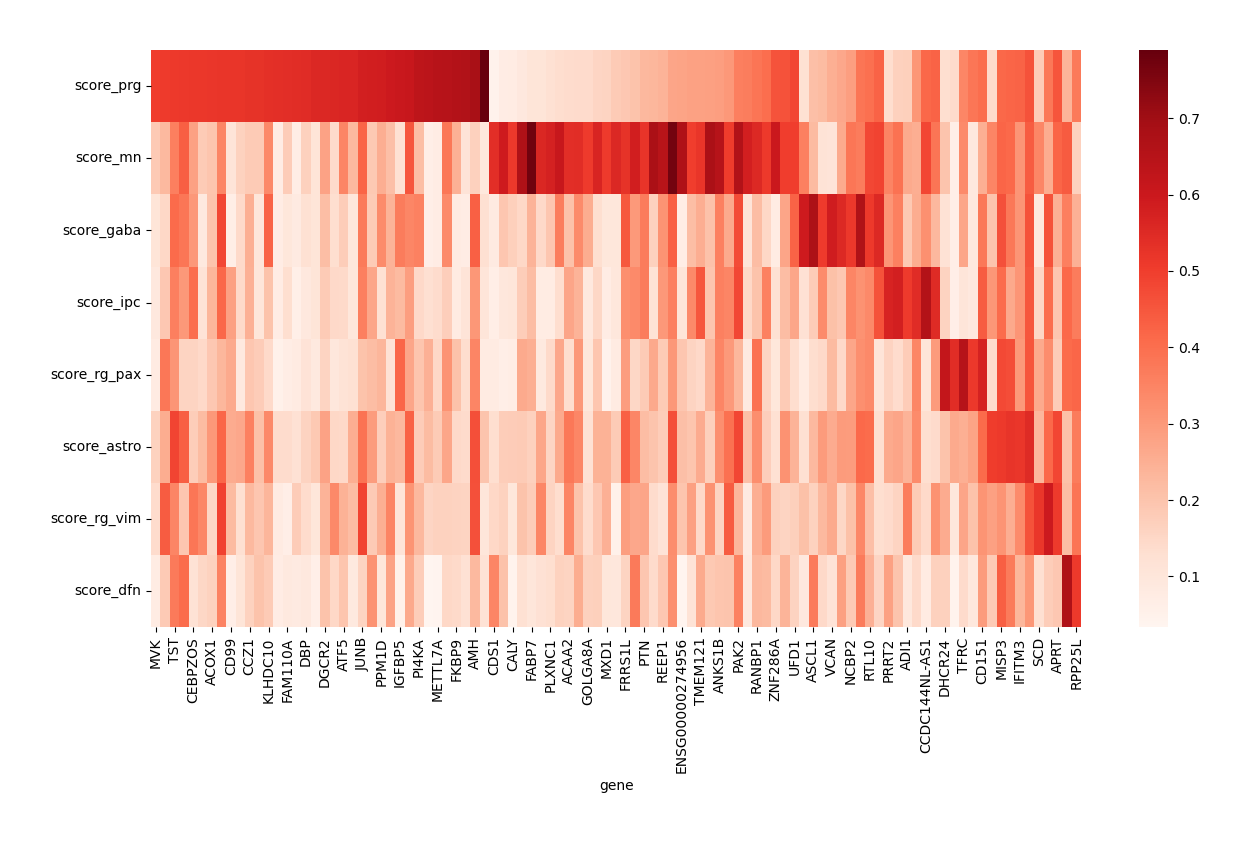

In [105]:
specific = combined[(combined > 0.5).sum(axis=1) == 1]

winner = (specific > 0.5).idxmax(axis=1)

# Count how many genes belong to each cell type
block_sizes = winner.value_counts()

# Order cell types from largest block to smallest
col_order = block_sizes.index.tolist()

# Reorder columns
specific = specific[col_order]

# Make winner a categorical with the desired ordering
winner = pd.Categorical(
    winner,
    categories=col_order,
    ordered=True
)

# Sort rows by block, then by score within each block
specific = (
    specific.assign(winner=winner)
            .sort_values(["winner"] + col_order, ascending=False)
            .drop(columns="winner")
)

specific = specific.iloc[::-1]

plt.figure(figsize=(15,7.5))
sns.heatmap(specific.T, yticklabels=True, cmap='Reds')
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_mashR_Heatmap.svg", bbox_inches='tight')

In [110]:
## Prep GO Plots On Mash Result ##

celltype_gene_mash_df = pd.DataFrame([[i.removeprefix('score_') for i in winner], specific.index], index=['celltype', 'gene']).T
mash_gseapy_dict = celltype_gene_mash_df.groupby('celltype').agg(list)['gene'].to_dict()

enrichr_results = []

for celltype in mash_gseapy_dict.keys():
    res = gp.enrichr(
        gene_list=mash_gseapy_dict[celltype],
        gene_sets='GO_Biological_Process_2026',
        organism='hs'
    ).results.copy()

    # add label
    res['celltype'] = celltype

    enrichr_results.append(res)

    time.sleep(1.5)

# combine everything
enrich_df = pd.concat(enrichr_results, ignore_index=True)

enrich_df['Term_cleaned'] = enrich_df['Term'].str.replace(r'\s*\(GO:[^)]+\)$', '', regex=True).str.strip()

enrich_df['neglogP'] = -np.log10(enrich_df['Adjusted P-value'])

/tmp/ipykernel_20236/2672265348.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  enrich_df = pd.concat(enrichr_results, ignore_index=True)


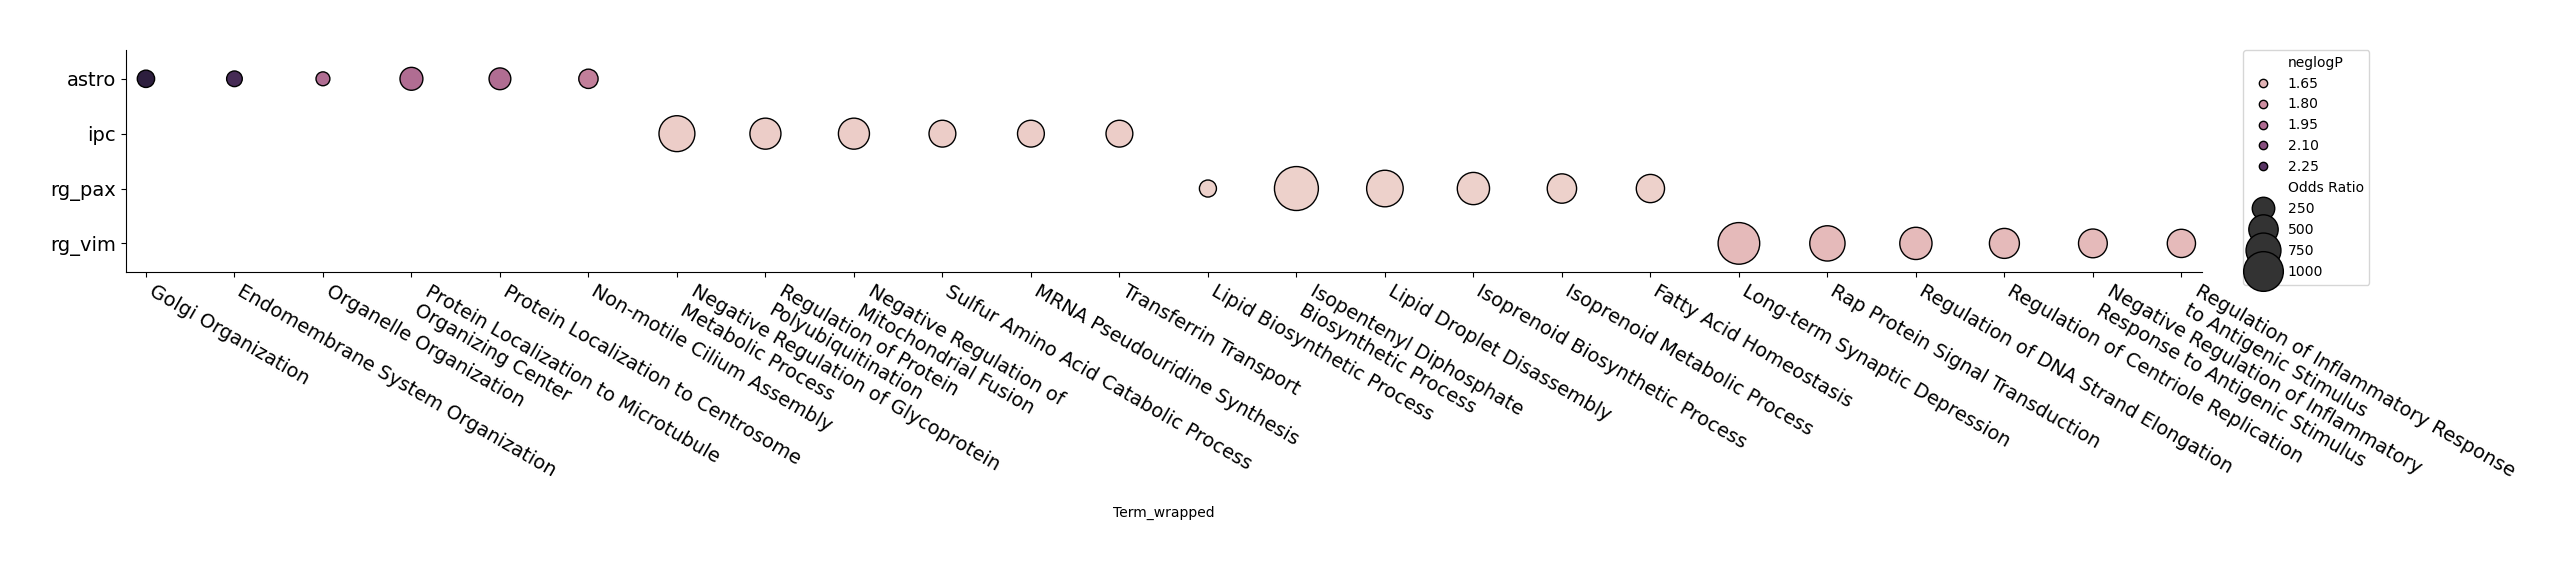

In [157]:
import textwrap

df = enrich_df[enrich_df['Adjusted P-value'] < 0.05].groupby('celltype').head(6).copy()

df["Term_wrapped"] = df["Term_cleaned"].apply(
    lambda x: "\n".join(textwrap.wrap(x, width=35))
)

plt.figure(figsize=(25, 5))

ax = sns.scatterplot(
    data=df,
    y='celltype',
    x='Term_wrapped',
    size='Odds Ratio',
    sizes=(100, 1000),
    hue='neglogP',
    edgecolor="black", linewidth=1.,
)

plt.xticks(rotation=-30, ha='left')

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)

ax.set_ylabel('')
ax.margins(x=0.01)  
ax.margins(y=.175)  
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('medium')
sns.despine(top=True, right=True)
plt.tight_layout()
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_mashR_GO_dotplot.svg", bbox_inches='tight')
plt.show()

In [106]:
def run_enrichr_for_groups(gene_sets, gene_set_db='KEGG_2016'):
    
    results = []

    for (disease, celltype), genes in gene_sets.items():

        if len(genes) < 5:   # avoid tiny unstable sets
            continue

        time.sleep(1.5)  

        enr = gp.enrichr(
            gene_list=genes,
            gene_sets=gene_set_db,
            organism='hs',
            outdir=None,
            no_plot=True
        )

        df = enr.results.copy()
        df['disease'] = disease
        df['celltype'] = celltype

        results.append(df)

    return pd.concat(results, ignore_index=True)

In [107]:
gene_sets = significant_all.groupby(['group', 'assay'])['ID'].apply(list)

enrich_df = run_enrichr_for_groups(gene_sets, gene_set_db='GO_Molecular_Function_2026')

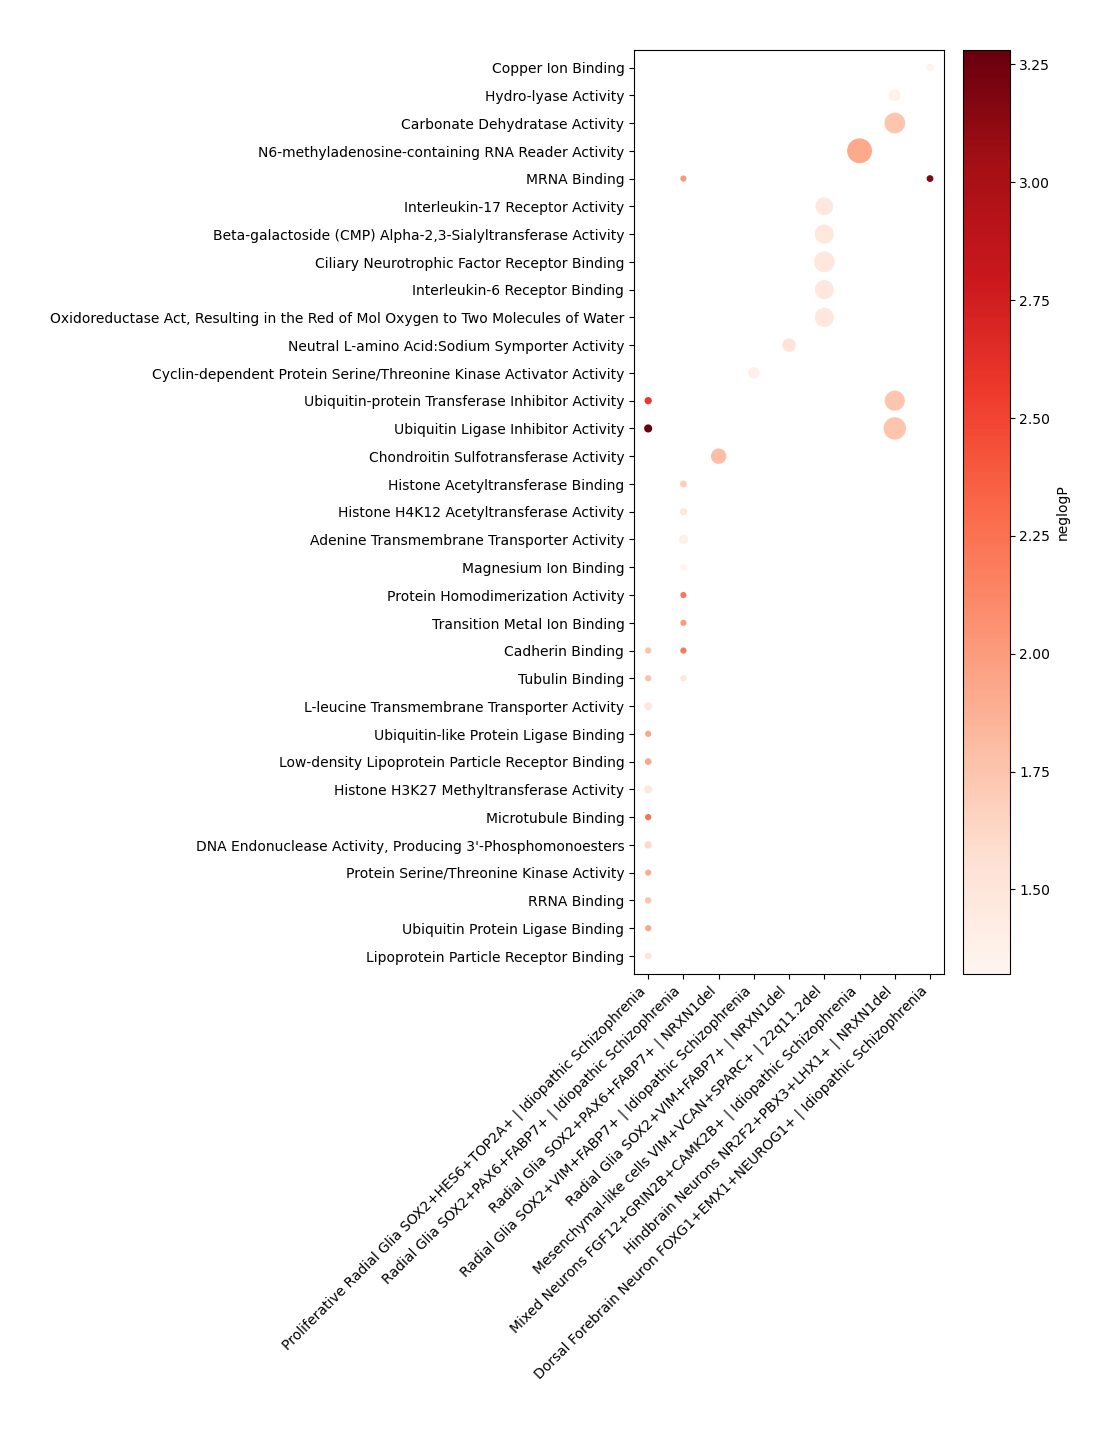

In [108]:
## Individual Signatures GO Plots ## 

plot_df = enrich_df.copy()
plot_df = plot_df[plot_df['Adjusted P-value'] < 0.05].copy()

plot_df['neglogp'] = -np.log10(plot_df['Adjusted P-value'].astype('float'))
plot_df['group'] = plot_df['celltype'] + " | " + plot_df['disease']

# -----------------------------
# AGGREGATE
# -----------------------------
agg = plot_df.groupby(['Term', 'group']).agg({
    'neglogp': 'max',
    'Combined Score': 'mean',
    'Odds Ratio': 'mean'
}).reset_index()

plot_long = agg.copy()

# -----------------------------
# ORDER GROUPS (CELLTYPE FIRST)
# -----------------------------
plot_long['celltype'] = plot_long['group'].str.split(" \\| ").str[0]

unique_celltypes = ['Proliferative Radial Glia SOX2+HES6+TOP2A+', 'Radial Glia SOX2+PAX6+FABP7+', 
                    'Radial Glia SOX2+VIM+FABP7+', 'Mesenchymal-like cells VIM+VCAN+SPARC+',
                    'Mixed Neurons FGF12+GRIN2B+CAMK2B+', 'Hindbrain Neurons NR2F2+PBX3+LHX1+',
                    'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+']

group_order = []
for ct in unique_celltypes:
    sub = sorted([g for g in plot_long['group'].unique() if g.startswith(ct + " | ")])
    group_order.extend(sub)

plot_long['group'] = pd.Categorical(plot_long['group'], categories=group_order, ordered=True)

# map x positions for ordering signal
group_to_num = {g: i for i, g in enumerate(group_order)}
plot_long['x_pos'] = plot_long['group'].map(group_to_num)

# -----------------------------
# TERM ORDER (CREATES DIAGONAL STRUCTURE)
# -----------------------------

plot_long['Term'] = plot_long['Term'].str.replace(r'\s*\(GO.*$', '', regex=True).str.strip()

term_order = (
    plot_long
    .groupby('Term')
    .apply(lambda d: np.average(d['x_pos'], weights=d['neglogp']))
    .sort_values()
    .index
    .tolist())

plot_long['Term'] = pd.Categorical(plot_long['Term'], categories=term_order, ordered=True)

plot_long['neglogp'] = plot_long['neglogp'].astype('float')

# -----------------------------
# PLOT
# -----------------------------

plot_long['Term'] = plot_long['Term'].cat.remove_unused_categories()

df = plot_long.copy()

# ensure numeric codes for categories
x = df['group'].astype('category').cat.codes
y = df['Term'].astype('category').cat.codes

norm = mpl.colors.Normalize(
    vmin=df['neglogp'].min(),
    vmax=df['neglogp'].max()
)

plt.figure(figsize=(5, 12))

plt.scatter(
    x,
    y,
    c=df['neglogp'],
    cmap='Reds',
    norm=norm,
    s=20 + (df['Odds Ratio'] - df['Odds Ratio'].min()) /
           (df['Odds Ratio'].max() - df['Odds Ratio'].min()) * 300,
    edgecolors='none'
)

plt.xticks(
    range(len(df['group'].astype('category').cat.categories)),
    df['group'].astype('category').cat.categories,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(df['Term'].astype('category').cat.categories)),
    df['Term'].astype('category').cat.categories
)

plt.colorbar(label='neglogP')
plt.margins(y=0.02)
plt.show()

In [ ]:
plot_df = enrich_df.copy()
plot_df = plot_df[plot_df['Adjusted P-value'] < 0.05].copy()

plot_df['neglogp'] = -np.log10(plot_df['Adjusted P-value'].astype('float'))
plot_df['group'] = plot_df['celltype'] + " | " + plot_df['disease']

# -----------------------------
# AGGREGATE
# -----------------------------
agg = plot_df.groupby(['Term', 'group']).agg({
    'neglogp': 'max',
    'Combined Score': 'mean',
    'Odds Ratio': 'mean'
}).reset_index()

plot_long = agg.copy()

# -----------------------------
# ORDER GROUPS (CELLTYPE FIRST)
# -----------------------------
plot_long['celltype'] = plot_long['group'].str.split(" \\| ").str[0]

unique_celltypes = ['Proliferative Radial Glia SOX2+HES6+TOP2A+', 'Radial Glia SOX2+PAX6+FABP7+', 
                    'Radial Glia SOX2+VIM+FABP7+', 'Mesenchymal-like cells VIM+VCAN+SPARC+',
                    'Mixed Neurons FGF12+GRIN2B+CAMK2B+', 'Hindbrain Neurons NR2F2+PBX3+LHX1+',
                    'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+']

group_order = []
for ct in unique_celltypes:
    sub = sorted([g for g in plot_long['group'].unique() if g.startswith(ct + " | ")])
    group_order.extend(sub)

plot_long['group'] = pd.Categorical(plot_long['group'], categories=group_order, ordered=True)

# map x positions for ordering signal
group_to_num = {g: i for i, g in enumerate(group_order)}
plot_long['x_pos'] = plot_long['group'].map(group_to_num)

# -----------------------------
# TERM ORDER (CREATES DIAGONAL STRUCTURE)
# -----------------------------

plot_long['Term'] = plot_long['Term'].str.replace(r'\s*\(GO.*$', '', regex=True).str.strip()

term_order = (
    plot_long
    .groupby('Term')
    .apply(lambda d: np.average(d['x_pos'], weights=d['neglogp']))
    .sort_values()
    .index
    .tolist())

plot_long['Term'] = pd.Categorical(plot_long['Term'], categories=term_order, ordered=True)

plot_long['neglogp'] = plot_long['neglogp'].astype('float')

# -----------------------------
# PLOT
# -----------------------------

plot_long['Term'] = plot_long['Term'].cat.remove_unused_categories()

df = plot_long.copy()

# ensure numeric codes for categories
y = df['group'].astype('category').cat.codes
x = df['Term'].astype('category').cat.codes

norm = mpl.colors.Normalize(
    vmin=df['neglogp'].min(),
    vmax=df['neglogp'].max()
)

plt.figure(figsize=(20, 2))

plt.scatter(
    x,
    y,
    c=df['neglogp'],
    cmap='Reds',
    norm=norm,
    s=20 + (df['Odds Ratio'] - df['Odds Ratio'].min()) /
           (df['Odds Ratio'].max() - df['Odds Ratio'].min()) * 300,
    edgecolors='none'
)

plt.yticks(
    range(len(df['group'].astype('category').cat.categories)),
    df['group'].astype('category').cat.categories,
    rotation=0,
    ha='right'
)

plt.xticks(range(len(df['Term'].astype('category').cat.categories)), df['Term'].astype('category').cat.categories,
           rotation=35, 
           ha='right')


plt.colorbar(label='neglogP')
plt.margins(x=0.02)
plt.margins(y=0.1)
plt.show()

In [ ]:
plot_df[['disease', 'celltype']].value_counts()

In [ ]:
gene_sets = significant_all.groupby(['group', 'assay'])['ID'].apply(list)

chea_df = run_enrichr_for_groups(gene_sets, gene_set_db='ChEA_2022')

In [ ]:
plot_df = chea_df.copy()
plot_df = plot_df[plot_df['Adjusted P-value'] < 0.000001].copy()

plot_df['neglogp'] = -np.log10(plot_df['Adjusted P-value'])
plot_df['group'] = plot_df['celltype'] + " | " + plot_df['disease']

# -----------------------------
# AGGREGATE
# -----------------------------
agg = plot_df.groupby(['Term', 'group']).agg({
    'neglogp': 'max',
    'Combined Score': 'mean',
    'Odds Ratio': 'mean'
}).reset_index()

plot_long = agg.copy()

# clean term labels (your version kept)
plot_long['Term_cleaned'] = plot_long['Term'].str.split(' ').apply(lambda x: " ".join(x[0:-3]))

# -----------------------------
# ORDER GROUPS (CELLTYPE FIRST)
# -----------------------------
plot_long['celltype'] = plot_long['group'].str.split(" \\| ").str[0]

group_order = []
for ct in plot_long['celltype'].unique():
    sub = sorted([g for g in plot_long['group'].unique() if g.startswith(ct + " | ")])
    group_order.extend(sub)

plot_long['group'] = pd.Categorical(plot_long['group'], categories=group_order, ordered=True)

# map x positions for ordering signal
group_to_num = {g: i for i, g in enumerate(group_order)}
plot_long['x_pos'] = plot_long['group'].map(group_to_num)

# -----------------------------
# TERM ORDER (CREATES DIAGONAL STRUCTURE)
# -----------------------------
term_order = (
    plot_long
    .groupby('Term')
    .apply(lambda d: np.average(d['x_pos'], weights=d['neglogp']))
    .sort_values()
    .index
    .tolist()
)

plot_long['Term'] = pd.Categorical(
    plot_long['Term'],
    categories=term_order,
    ordered=True
)

plot_long = plot_long.sort_values(['group', 'Term'])

plot_long['Term_cleaned'] = plot_long['Term'].str.replace(r'\s*ChIP-.*$', '', regex=True, case=False).str.strip()

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(10, 20))

sns.scatterplot(
    data=plot_long,
    x='group',
    y='Term_cleaned',
    size='Odds Ratio',
    hue='neglogp',
    sizes=(20, 300),
    edgecolor=None
)

plt.xticks(rotation=45, ha='right')
plt.title("Enrichment Dot Plot (diagonal-ordered)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
names = gp.get_library_name()

In [ ]:
names

In [ ]:
## Find Duplicates in Dorsal DGE ##

dc_significant_all_dorsal[dc_significant_all_dorsal['ID'].duplicated(keep=False)]

In [ ]:
## Find Duplicates in RG VIM+ DGE ##

dc_significant_all_rg_vim[dc_significant_all_rg_vim['ID'].duplicated(keep=False)]

In [ ]:
## Find Duplicates in proliferative RGs ##

dc_significant_all_prg[dc_significant_all_prg['ID'].duplicated(keep=False)]

In [ ]:
dc_significant_all_dorsal[dc_significant_all_dorsal['ID'].duplicated(keep=False)]

In [ ]:
forest_dfs = pd.concat([dc_significant_all_rg_vim[dc_significant_all_rg_vim['ID'].duplicated(keep=False)],
              dc_significant_all_prg[dc_significant_all_prg['ID'].duplicated(keep=False)],
              dc_significant_all_dorsal[dc_significant_all_dorsal['ID'].duplicated(keep=False)]], axis=0)

In [ ]:

# MANUAL COLORS
META_COLOR = "#000000"

STUDY_COLORS = {
    "logFC_sawada": "#E64B35",
    "logFC_notaras": "#4DBBD5",
    "logFC_sebastian": "#00A087",
    "logFC_fernando": "#3C5488",
    "logFC_rao": "#F39B7F",
    "logFC_shin": "#8491B4",
    "logFC_walsh": "#91D1C2",
}

# =====================================================
# SPACING CONTROL
# =====================================================

WITHIN_GENE_SPACING = 0.7
BETWEEN_GENE_SPACING = 1.5

# =====================================================
# Prepare data
# =====================================================

df = forest_dfs.copy()

logfc_cols = [c for c in df.columns if c.startswith("logFC_")]

df = df.sort_values(["assay", "group"])
df["label"] = df["group"]

# =====================================================
# Custom grouped y positions
# =====================================================

y_positions = []
current_y = 0
prev_gene = None

for _, row in df.iterrows():

    gene = row["assay"]

    if prev_gene is None:
        pass
    elif gene == prev_gene:
        current_y -= WITHIN_GENE_SPACING
    else:
        current_y -= BETWEEN_GENE_SPACING

    y_positions.append(current_y)
    prev_gene = gene

df["y"] = y_positions
df["y"] = df["y"] - df["y"].min()

fig, ax = plt.subplots(figsize=(19, 7))

# GRID CONTROL (EDIT THIS BLOCK)

ax.grid(
    True,
    axis='both',          
    color='#E5E5E5',
    linestyle=':',
    linewidth=0.7,
    alpha=0.8)

# PLOT

for _, row in df.iterrows():

    y = row["y"]

    est = row["estimate"]
    se = row["std.error"]

    ci_low = est - 1.96 * se
    ci_high = est + 1.96 * se

    # meta-analysis
    ax.errorbar(
        est,
        y,
        xerr=[[est - ci_low], [ci_high - est]],
        fmt='s',
        markersize=25,
        color=META_COLOR,
        ecolor=META_COLOR,
        elinewidth=2.5,
        capsize=4,
        markeredgecolor='black',
        zorder=4)

    # individual studies
    study_vals = row[logfc_cols].dropna()
    offsets = np.linspace(-0.15, 0.15, len(study_vals))

    for offset, (col, val) in zip(offsets, study_vals.items()):

        color = STUDY_COLORS.get(col, "#808080")

        ax.scatter(
            val,
            y + offset,
            s=678,
            color=color,
            alpha=0.9,
            edgecolor='black',
            linewidth=1.5,
            zorder=3)

# AXIS FORMATTING

ax.axvline(0, linestyle='--', color='black', alpha=0.5)

ax.set_yticks(df["y"])
ax.set_yticklabels(df["label"])
# # gene labels
# gene_midpoints = df.groupby("assay_ID")["y"].mean()

# for gene, y in gene_midpoints.items():
#     ax.text(
#         ax.get_xlim()[0] - 0.15,
#         y,
#         gene,
#         ha='right',
#         va='center',
#         fontsize=13
#     )

# LEGEND

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=col.replace("logFC_", ""),
        markerfacecolor=color,
        markersize=9)
    for col, color in STUDY_COLORS.items()
]

legend_elements.insert(
    0,
    Line2D([0], [0],
        marker='s',
        color=META_COLOR,
        label='Meta-analysis',
        markersize=10,
        linewidth=2)
)

ax.legend(
    handles=legend_elements,
    title="Study",
    bbox_to_anchor=(1.02, 1),
    loc='upper left')

ax.tick_params(axis='x', labelsize=25)
ax.tick_params(axis='y', labelsize=30)
ax.set_xlabel("logFC", fontsize=30)
ax.set_title("Forest Plot with Study Contributions", fontsize=30)

sns.despine()
# plt.tight_layout()
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_forest_plot.svg", format="svg", bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
# MANUAL COLORS

META_COLOR = "#000000"

STUDY_COLORS = {
    "logFC_sawada": "#E64B35",
    "logFC_notaras": "#4DBBD5",
    "logFC_sebastian": "#00A087",
    "logFC_fernando": "#3C5488",
    "logFC_rao": "#F39B7F",
    "logFC_shin": "#8491B4",
    "logFC_walsh": "#91D1C2"}

# SPACING CONTROL (NOW ON X-AXIS)

WITHIN_GENE_SPACING = 0.7
BETWEEN_GENE_SPACING = 1.2

# PREPARE DATA

df = forest_dfs.copy()

logfc_cols = [c for c in df.columns if c.startswith("logFC_")]

df = df.sort_values(["assay", "group"])
df["label"] = df["group"]

# CUSTOM X POSITIONS (NOW GROUPED ON X-AXIS)

x_positions = []
current_x = 0
prev_gene = None

for _, row in df.iterrows():

    gene = row["assay"]

    if prev_gene is None:
        pass
    elif gene == prev_gene:
        current_x -= WITHIN_GENE_SPACING
    else:
        current_x -= BETWEEN_GENE_SPACING

    x_positions.append(current_x)
    prev_gene = gene

df["x"] = x_positions
df["x"] = df["x"] - df["x"].min()

# STYLE

sns.set_style("white")
sns.set_context("paper", font_scale=1.1)

fig, ax = plt.subplots(figsize=(7,7))

# GRID

ax.grid(
    True,
    axis='y',
    color='#EAEAEA',
    linestyle=':',
    linewidth=0.8,
    alpha=0.9
)

ax.xaxis.grid(False)
ax.set_axisbelow(True)

# DRAW PLOT (SWAPPED)

for _, row in df.iterrows():

    x = row["x"]

    est = row["estimate"]
    se = row["std.error"]

    ci_low = est - 1.96 * se
    ci_high = est + 1.96 * se

    # -------------------------------------------------
    # META-ANALYSIS (NOW VERTICAL = y-axis)
    # -------------------------------------------------
    ax.errorbar(
        x,
        est,
        yerr=[[est - ci_low], [ci_high - est]],
        fmt='s',
        markersize=20,
        color=META_COLOR,
        ecolor=META_COLOR,
        elinewidth=2.0,
        capsize=4,
        markeredgecolor='black',
        zorder=4
    )

    # STUDY POINTS
    study_vals = row[logfc_cols].dropna()
    offsets = np.linspace(-0.15, 0.15, len(study_vals))

    for offset, (col, val) in zip(offsets, study_vals.items()):

        color = STUDY_COLORS.get(col, "#808080")

        ax.scatter(
            x + offset,
            val,
            s=200,
            color=color,
            alpha=0.95,
            edgecolor='black',
            linewidth=1.2,
            zorder=5
        )

# AXIS FORMATTING

ax.axhline(0, linestyle=':', color='black', alpha=0.6)

ax.set_xticks(df["x"])
ax.set_xticklabels(df["label"])

ax.set_xlabel("Group")
ax.set_ylabel("logFC")

# # GENE LABELS (BOTTOM, NOT TOP)

# gene_midpoints = df.groupby("assay_ID")["x"].mean()

# y_bottom = ax.get_ylim()[0] - 1  # small padding below axis

# for gene, x in gene_midpoints.items():
#     ax.text(
#         x,
#         y_bottom,
#         gene,
#         ha='center',
#         va='top',
#         fontsize=12
#     )

# LEGEND
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=col.replace("logFC_", ""),
        markerfacecolor=color,
        markeredgecolor='black',
        markersize=8
    )
    for col, color in STUDY_COLORS.items()
]

legend_elements.insert(
    0,
    Line2D(
        [0], [0],
        marker='s',
        color=META_COLOR,
        label='Meta-analysis',
        markersize=9,
        linewidth=2
    )
)

ax.legend(
    handles=legend_elements,
    title="Study",
    bbox_to_anchor=(1.02, 1),
    loc='upper left')

plt.setp(
    ax.get_xticklabels(),
    rotation=-30,
    ha='left',
    # rotation_mode='anchor'
)

ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=15)
ax.set_xlabel("")
ax.set_ylabel("logFC", fontsize=25)
ax.set_title("Forest Plot", fontsize=25)

# =====================================================
# FINAL CLEANUP
# =====================================================

sns.despine(top=True, right=True)
plt.tight_layout()

plt.savefig(
    "/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_forest_plot_swapped.svg",
    format="svg",
    bbox_inches="tight",
    dpi=300)

plt.show()

In [ ]:
wwc_forest_plots = pd.concat([dc_significant_idiopathic_df_logfc[dc_significant_idiopathic_df_logfc['ID'] == 'WWC2'],
                              dc_significant_22q11_df_logfc[dc_significant_22q11_df_logfc['ID'] == 'WWC2'],
                              dc_significant_nrxn1_df_logfc[dc_significant_nrxn1_df_logfc['ID'] == 'WWC2']], axis=0)

In [ ]:
wwc_forest_plots

In [ ]:
# =====================================================
# FOREST PLOT FOR SINGLE GENE (WWC2)
# Assays = x-axis
# logFC = y-axis
# Meta-analysis estimate = square + CI
# Individual studies = colored circles
# =====================================================

# =====================================================
# MANUAL COLORS
# =====================================================

META_COLOR = "#000000"

STUDY_COLORS = {
    "logFC_sawada": "#E64B35",
    "logFC_notaras": "#4DBBD5",
    "logFC_sebastian": "#00A087",
    "logFC_fernando": "#3C5488",
    "logFC_rao": "#F39B7F",
    "logFC_shin": "#8491B4",
    "logFC_walsh": "#91D1C2",
}

# =====================================================
# SPACING
# =====================================================

COLUMN_SPACING = 0.2

# =====================================================
# PREPARE DATA
# =====================================================

df = wwc_forest_plots.copy()

# all study-level logFC columns
logfc_cols = [c for c in df.columns if c.startswith("logFC_")]

# sort assays
df = df.sort_values("estimate", ascending=False)

# assay labels
df["label"] = df["assay"]

# x positions
df["x"] = np.arange(len(df)) * COLUMN_SPACING

# =====================================================
# FIGURE
# =====================================================

fig, ax = plt.subplots(figsize=(7, 7))

# =====================================================
# GRID
# =====================================================

ax.grid(
    True,
    axis='both',
    color='#E5E5E5',
    linestyle=':',
    linewidth=0.7,
    alpha=0.8
)

# =====================================================
# PLOT
# =====================================================

for _, row in df.iterrows():

    x = row["x"]

    # meta-analysis estimate
    est = row["estimate"]
    se = row["std.error"]

    ci_low = est - 1.96 * se
    ci_high = est + 1.96 * se

    # ---------------------------------------------
    # META-ANALYSIS CI LINE
    # ---------------------------------------------

    ax.vlines(
        x=x,
        ymin=ci_low,
        ymax=ci_high,
        color=META_COLOR,
        linewidth=2.5,
        zorder=1
    )

    # CI caps
    ax.hlines(
        [ci_low, ci_high],
        x - 0.04,
        x + 0.04,
        color=META_COLOR,
        linewidth=2,
        zorder=1
    )

    # ---------------------------------------------
    # META-ANALYSIS SQUARE
    # ---------------------------------------------

    ax.scatter(
        x,
        est,
        marker='s',
        s=260,
        color=META_COLOR,
        edgecolor='black',
        linewidth=1.2,
        zorder=2
    )

    # ---------------------------------------------
    # INDIVIDUAL STUDIES
    # ---------------------------------------------

    study_vals = row[logfc_cols].dropna()

    offsets = np.linspace(-0.05, 0.05, len(study_vals))

    for offset, (col, val) in zip(offsets, study_vals.items()):

        color = STUDY_COLORS.get(col, "#808080")

        ax.scatter(
            x + offset,
            val,
            s=220,
            color=color,
            alpha=0.95,
            edgecolor='black',
            linewidth=1.3,
            zorder=5)

# =====================================================
# AXIS FORMATTING
# =====================================================

# zero line
ax.axhline(
    0,
    linestyle='--',
    color='black',
    alpha=0.5
)

# x labels
ax.set_xticks(df["x"])
ax.set_xticklabels(
    df["label"],
    rotation=25,
    ha='right'
)

# =====================================================
# LEGEND
# =====================================================

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=col.replace("logFC_", ""),
        markerfacecolor=color,
        markeredgecolor='black',
        markersize=10
    )
    for col, color in STUDY_COLORS.items()
]

legend_elements.insert(
    0,
    Line2D(
        [0], [0],
        marker='s',
        color=META_COLOR,
        label='Meta-analysis',
        markersize=11,
        linewidth=2)
)

ax.legend(handles=legend_elements, title="Study", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12, title_fontsize=13)

# =====================================================
# FINAL FORMATTING
# =====================================================

sns.despine()

ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=15)

ax.set_xticks(df["x"])

ax.set_xticklabels(
    df["label"],
    rotation=-30,
    ha='left')

# tick sizes
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=15)
ax.set_ylabel("logFC", fontsize=25)
ax.set_title("WWC Forest Plot", fontsize=25)


plt.savefig(
    "/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_WWC2_forest_plot_vertical.svg",
    format="svg",
    bbox_inches="tight",
    dpi=300)

plt.show()

In [ ]:
# dge_fernando = pd.read_csv(Path(CSV_PATH) / 'dreamlet_fernando_dge_scz_results.csv')
# dge_shin = pd.read_csv(Path(CSV_PATH) / 'dreamlet_shin_dge_scz_results.csv')
# dge_purcell = pd.read_csv(Path(CSV_PATH) / 'dreamlet_purcell_dge_scz_results.csv')
# dge_sebastian = pd.read_csv(Path(CSV_PATH) / 'dreamlet_sebastian_dge_scz_results.csv')
# dge_sawada = pd.read_csv(Path(CSV_PATH) / 'dreamlet_sawada_dge_scz_results.csv')
# dge_notaras = pd.read_csv(Path(CSV_PATH) / 'dreamlet_notaras_dge_scz_results.csv')
# dge_rao = pd.read_csv(Path(CSV_PATH) / 'dreamlet_rao_dge_scz_results.csv')
# dge_walsh_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_22q11_dge_scz_results.csv')
# dge_walsh_15q13 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_15q13_dge_scz_results.csv')

# dge_lists = [dge_fernando, dge_shin, dge_purcell, dge_sebastian, dge_sawada, dge_notaras,  dge_rao,
#              dge_walsh_22q11, dge_walsh_15q13]

In [ ]:
# for dge in dge_lists:
#     dge_dataset = str(dge['dataset'][0])
#     dge.rename({'logFC': f"logFC_{dge_dataset}",
#                      'AveExpr': f"AveExpr_{dge_dataset}",
#                      't': f"t_{dge_dataset}",
#                      'P.Value': f"P.Value_{dge_dataset}",
#                      'adj.P.Val': f"adj.P.Val_{dge_dataset}",
#                      'B': f"B_{dge_dataset}",
#                      'z.std': f"z.std_{dge_dataset}",
#                      'dataset': f"dataset_{dge_dataset}"}, axis=1, inplace=True)

In [ ]:
# keys = ['assay', 'ID']

# merged = reduce(lambda left, right: pd.merge(left, right, on=keys, how='outer'), dge_lists)

# merged_logFC = merged[[i for i in merged.columns if (('logFC' in i) or ('assay' in i) or ('ID' in i))]]

In [ ]:
# ## iterate through celltypes, print the lowest dominator, subset to that lowest dominator, 

# for celltype in merged_logFC['assay'].unique():

#     print(celltype)
#     merged_logFC_temp = merged_logFC[merged_logFC['assay'] == celltype]

#     merged_logFC_temp.index = merged_logFC_temp['assay'].astype('str') + '_' + merged_logFC_temp['ID'].astype('str')
#     del merged_logFC_temp['assay']
#     del merged_logFC_temp['ID']

#     # lowest common denominator #
#     print(merged_logFC_dfn.notnull().sum(axis=0))

In [ ]:
dge_idiopathic

In [ ]:
idiopathic_mat = dge_idiopathic.pivot_table(index='assay', columns='ID', values='estimate')
idiopathic_mat.index = 'Idiopathic | ' + idiopathic_mat.index

x22q11_mat = dge_22q11.pivot_table(index='assay', columns='ID', values='estimate')
x22q11_mat.index = '22q11 | ' + x22q11_mat.index

nrxn1_mat = dge_nrxn1.pivot_table(index='assay', columns='ID', values='estimate')
nrxn1_mat.index = 'NRXN1 | ' + nrxn1_mat.index

all_dx_celltype = pd.concat([idiopathic_mat, x22q11_mat, nrxn1_mat], axis=0)

In [ ]:
all_dx_celltype

In [ ]:
g = sns.clustermap(
    all_dx_celltype.T.corr(),
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    figsize=(13.5, 9),  
    xticklabels=False)

g.ax_heatmap.set_ylabel('')
g.ax_heatmap.set_xlabel('')
g.ax_heatmap.tick_params(axis='y', labelsize=16)

# save figure
g.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_disease_celltype_clustermap.svg",
          dpi=300, bbox_inches='tight')

In [ ]:
corr = all_dx_celltype.T.corr()

records = []

for row in corr.index:
    for col in corr.columns:

        # avoid duplicates + self correlations
        if row >= col:
            continue

        disease1 = row.split(' | ')[0]
        disease2 = col.split(' | ')[0]

        records.append({
            'disease': disease1,
            'comparison': (
                'within'
                if disease1 == disease2
                else 'outside'
            ),
            'correlation': corr.loc[row, col]
        })

        records.append({
            'disease': disease2,
            'comparison': (
                'within'
                if disease1 == disease2
                else 'outside'
            ),
            'correlation': corr.loc[row, col]
        })

plot_df = pd.DataFrame(records)